## Домашнее задание
Как найти стог сена в иголке? Практический проект по построению системы поиска аномалий.

### Цель:
В этом домашнем задании вам предстоит настроить систему по поиску аномалий в банковских транзакциях. Мало того, что аномальных значений в данных меньше одного процента, так еще и переменные анонимизированные и представляют собой первые 28 главных компонент, полученных после PCA преобразования оригинальных данных (о которых мы ничего не знаем).

Смогут ли бравые unsupervised методы справиться с такой задачей? Можно ли работать в таких условиях? Кто подставил кролика Роджера? Ответы на некоторые их этих вопросов вы узнаете после выполнения задания :)

### Описание/Пошаговая инструкция выполнения домашнего задания:

1. Скачайте датасет с https://www.kaggle.com/mlg-ulb/creditcardfraud#creditcard.csv
2. Проведите небольшой EDA (гистограммы и описательные статистики - обязательно).
3. Воспользуйтесь процентом аномалий, подсчитанным по переменной Class, как "экспертной оценкой" загрязненности нашего датасета.
4. Попробуйте построить различные модели и алгоритмы, разобранные на занятии, используя полученную экспертную оценку для настройки параметров.
5. Воспользуйтесь стандартными методами оценки качества бинарной классификации (особенно хорошо подойдёт classification report и confusion matrix), и, используя предсказания моделей и переменную Class, проверьте, действительно ли модели справляются со своей задачей и насколько хорошо они это делают.
6. При помощи tSNE и/или UMAP, постройте сжатое представление исходных данных и проверьте, действительно ли аномалии лежат достаточно далеко от основной массы точек.

### Критерии оценки:
- Базовый EDA - 2 балла.
- Построены различные алгоритмы по поиску аномалий (основанные на расстояниях, плотностях и используя модели) - 5 баллов.
- Проверка качества и отображение на сжатое пространство - 3 балла.

## Решение

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Наблюдаются проблемы с автоматическим определением числа ядер
# Закомментировать строки ниже для отличной конфигурации от 24 CPU
import os
os.environ['OMP_NUM_THREADS'] = '22'
os.environ['LOKY_MAX_CPU_COUNT '] = '22'

In [24]:
# Файл достаточно большой (150 Mb), поэтому под управление VSC его не добавил
# При необходимости следуюет его следует скачать самостоятельно https://www.kaggle.com/mlg-ulb/creditcardfraud#creditcard.csv
df = pd.read_csv('./creditcard.csv', sep=',')

### EDA

In [25]:
print(f'Shape: {df.shape}')
print(f'Пропуски: {df.isnull().sum().sum()}')
print(f'Типы данных: {df.dtypes.unique()}')
print(f'Столбцы: {df.columns}')
print(f'Распределение по классам: {df['Class'].value_counts() / df.shape[0] * 100}')

Shape: (284807, 31)
Пропуски: 0
Типы данных: [dtype('float64') dtype('int64')]
Столбцы: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')
Распределение по классам: Class
0    99.827251
1     0.172749
Name: count, dtype: float64


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

**Предварительные выводы о данных**:
1. Пропусков нет.
2. Все столбцы числовые.
3. Полагая, что класс 1 идентифицирует аномалии, делаю вывод, что процент аномалий в исходном датасете состовляет 0.17%

In [27]:
# Перемещение ряда столбцов для лучшей визуализации
sorted_columns = ['Class', 'Amount']
sorted_df = pd.concat([df[sorted_columns], df.drop(sorted_columns, axis=1)], axis=1)
sorted_df.head()

,Class,Amount,Time,V1,V2,V3,V4,V5,V6,V7,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
0,0,149.62,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,...,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053
1,0,2.69,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,...,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724
2,0,378.66,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,...,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752
3,0,123.50,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,...,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458
4,0,69.99,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,...,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153


In [28]:
sorted_df.describe()

,Class,Amount,Time,V1,V2,V3,V4,V5,V6,V7,...,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28
count,284807.000000,284807.000000,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05
mean,0.001727,88.349619,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,...,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16
std,0.041527,250.120109,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,...,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01
min,0.000000,0.000000,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,...,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01
25%,0.000000,5.600000,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,...,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02
50%,0.000000,22.000000,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,...,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02
75%,0.000000,77.165000,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,...,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02
max,1.000000,25691.160000,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,...,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01


array([[<Axes: title={'center': 'Class'}>,
        <Axes: title={'center': 'Amount'}>,
        <Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>],
       [<Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>,
        <Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>],
       [<Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>,
        <Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>],
       [<Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>,
        <Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>],
       [<Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>,
        <Axes: title={'center

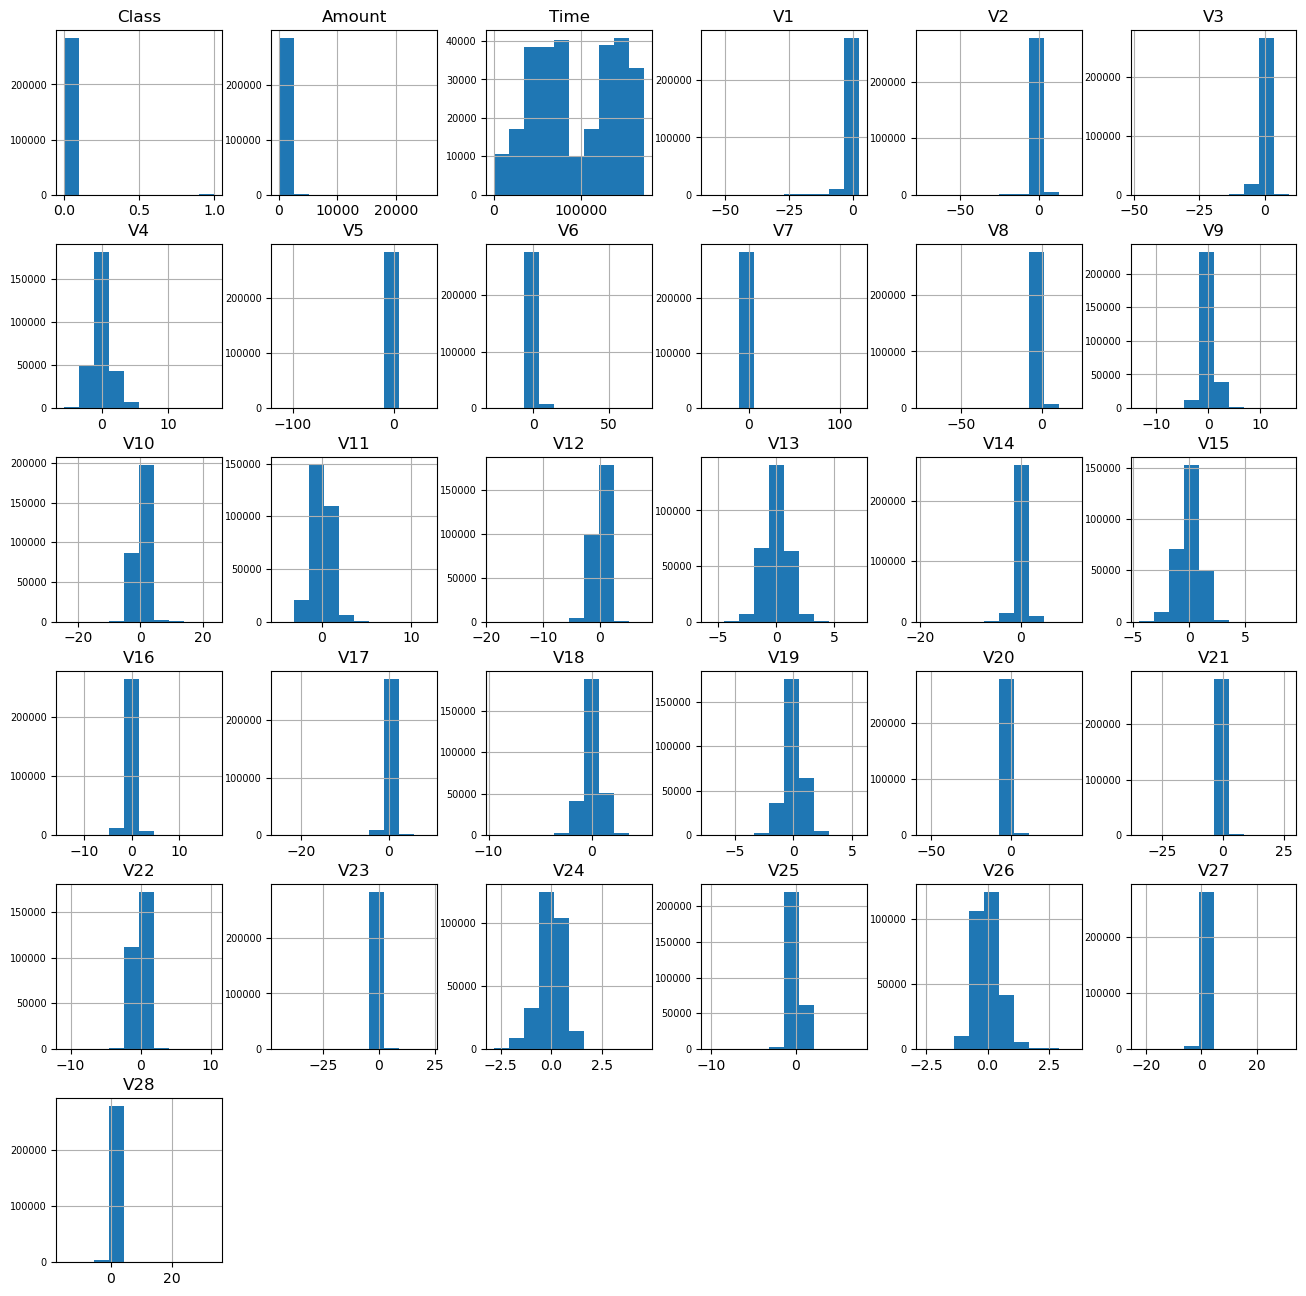

In [29]:
sorted_df.hist(figsize=(16,16), ylabelsize=7)

<Axes: >

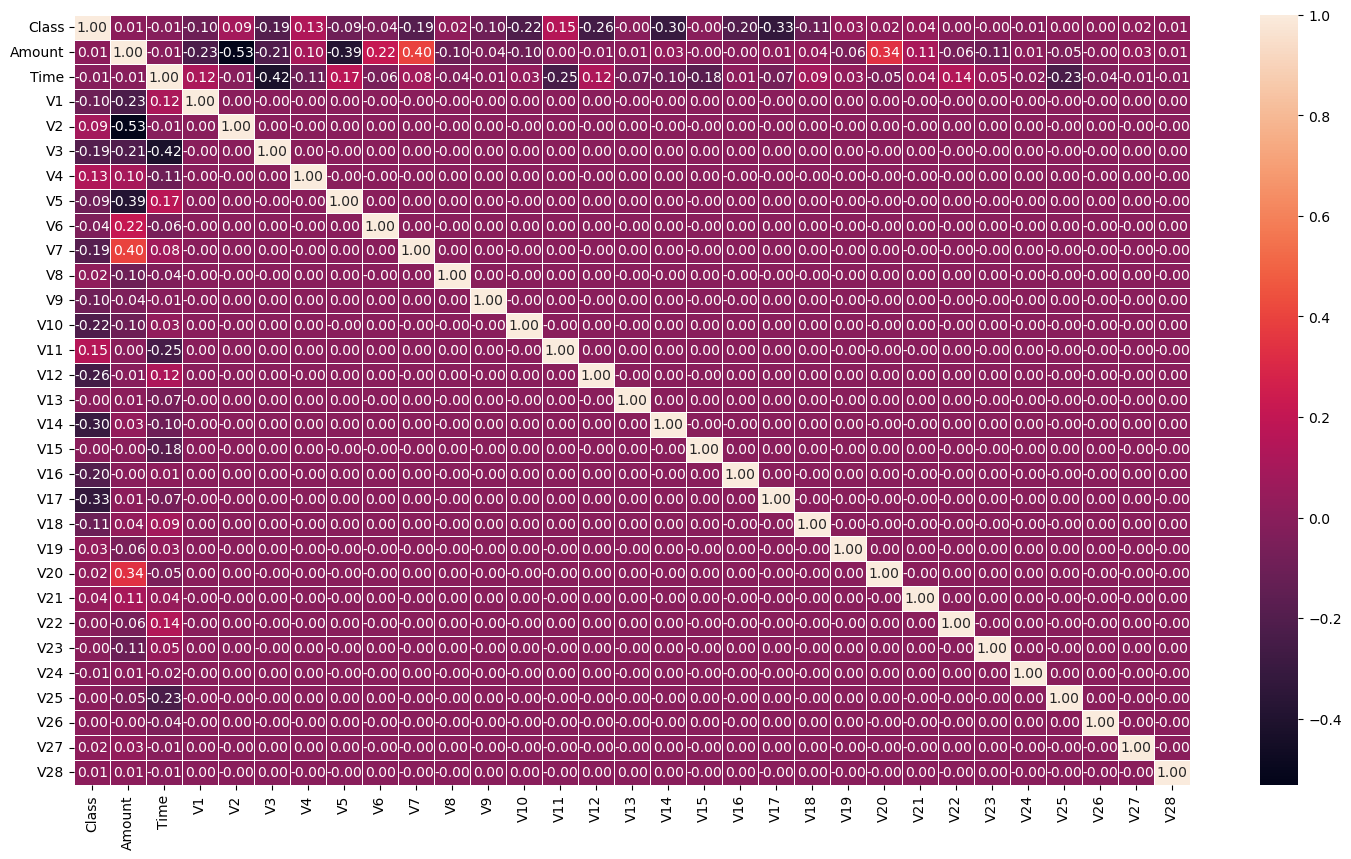

In [30]:
plt.figure(figsize=(18, 10))
sorted_df_corr = sorted_df.corr()
sns.heatmap(sorted_df_corr, annot=True, cbar=True, linewidths=.5, fmt= '.2f')

**Вывод по корреляции**: целевая переменная имеет слабую отрицательную связь с признаками V14 и V17.

### Вспомогательные функции и преобразования

In [31]:
# Отделение целевой переменной
y = df['Class']
df = df.drop('Class', axis=1)

In [32]:
# Разбиение исходного множества наблюдений
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=5, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=5, stratify=y_train
)

print(f'''Размеры наборов:
      Train: {X_train.shape}
      Test: {X_test.shape}
      Val: {X_val.shape}''')

print(f'''Доли целевой переменной в каждом наборе:
      Train\n{y_train.value_counts(normalize=True)}
      Test\n{y_test.value_counts(normalize=True)}
      Val\n{y_val.value_counts(normalize=True)}''')

Размеры наборов:
      Train: (170883, 30)
      Test: (56962, 30)
      Val: (56962, 30)
Доли целевой переменной в каждом наборе:
      Train
Class
0    0.998274
1    0.001726
Name: proportion, dtype: float64
      Test
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64
      Val
Class
0    0.998262
1    0.001738
Name: proportion, dtype: float64


In [34]:
from sklearn.manifold import TSNE
from umap import UMAP

SET_VAL = 'VAL'
SET_TEST = 'TEST'

dim_reductions = dict()
for set_type, X, y_true in [(SET_VAL, X_val, y_val), (SET_TEST, X_test, y_test)]:

    tsne = TSNE(n_components=2, random_state=10)
    X_tsne = tsne.fit_transform(X)

    umap = UMAP(n_components=2)
    X_umap = umap.fit_transform(X)

    dim_reductions[set_type] = [('TSNE', X_tsne, y_true), ('UMAP', X_umap, y_true)]

In [ ]:
# Определение столбцов с корреляцией для построения pairplot
corr_matrix = df.corr()
matrix_without_diagonal = corr_matrix[corr_matrix != 1]

columns_with_corr = [
    column for column in matrix_without_diagonal.columns if any((matrix_without_diagonal[column] > 0.25)|(matrix_without_diagonal[column] < -0.25))
]
columns_with_corr

['Time', 'V2', 'V3', 'V5', 'V7', 'V20', 'Amount']

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GridSearchCV

# Соединение представления сниженной размерности со столбцом с закодированным истинным значением выброса и предсказания.
# 0 - выброса нет, 1 - выброс истинный, 2 - выброс предсказанный, 3 - предсказание совпало
def concat_dim_reduction_data_with_outliers(X, y, outliers, anomalies_only=False):
    y_anomalies = pd.DataFrame(y + outliers * 2, columns=['Class'])
    X_concated = pd.concat([pd.DataFrame(X, index=y.index), y_anomalies], axis=1)
    if anomalies_only:
        X_concated = X_concated[X_concated.iloc[:,-1] > 0]
    return X_concated

# Визуализация в сниженной размерности
# Возможны вариантиы вывода только аномалий или всего множества
def print_in_dim_reductions(set_type, title, outliers, anomalies_only=False):       
    fig, axs = plt.subplots(ncols=len(dim_reductions), figsize=(16, 4))

    for i, (method, X, y) in enumerate(dim_reductions[set_type]):
        X_filtered = concat_dim_reduction_data_with_outliers(X, y, outliers, anomalies_only)
        g = sns.scatterplot(x=X_filtered.iloc[:,0], y=X_filtered.iloc[:,1], hue=X_filtered.iloc[:,2], palette='tab10', ax=axs[i])
        g.set_title(f'{set_type}, {method}, {"A/o," if anomalies_only else ""} {title if title is not None else ""}')
        g.set(xticklabels=[], xlabel=None)
        g.set(yticklabels=[], ylabel=None)

    fig.tight_layout()
      
def anomalies_report(y_true, y_pred):
    print(f'''
    Истинные аномалии: 
        Количество: {sum(y_true)}
        Процент:   {100*sum(y_true)/len(y_true):.2f}%
    Предсказанные аномалии:
        Количество: {sum(y_pred)}
        Процент:   {100*sum(y_pred)/len(y_pred):.2f}%''')

# Аномалии на нескольких графиках попарного сравнения
def print_pair_plot(X, y, outliers):
    X_concated = concat_dim_reduction_data_with_outliers(X, y, outliers)
    
    sns.pairplot(data=X_concated,
                hue='Class',
                vars = columns_with_corr,
                palette='tab10',
                plot_kws={'alpha': 0.6},
                corner=True)        
    
def print_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true=y_true, y_pred=y_pred)
    _, ax = plt.subplots(figsize=(4, 4))
    display_matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
    display_matrix.plot(ax=ax)

# Вывод всех результатов
def print_all(set_type, title, X, y_true, y_pred, anomalies_only=False):
    print_in_dim_reductions(set_type, title, y_pred, anomalies_only=True)
    print_confusion_matrix(y_true=y_true, y_pred=y_pred)
    print(f'Метрики классификации:\n{classification_report(y_true=y_true, y_pred=y_pred)}')
    anomalies_report(y_true, y_pred)
    print_pair_plot(X=X, y=y_true, outliers=y_pred)

# Кросс-валидация и применение лучшей модели
def cv_processing(classifier, param_grid, X_train, y_train, X_test, verbose=1):
    grid_search = GridSearchCV(classifier, param_grid, cv=5, scoring='f1', verbose=verbose)
    grid_search.fit(X_train, y_train)
    print(f'Лучшие параметры CV: {grid_search.best_params_}\nЛучшая метрика обучения CV: {abs(grid_search.best_score_)}')
    y_predict = grid_search.best_estimator_.predict(X_test)
    return y_predict

### Моделирование

In [ ]:
from sklearn.base import BaseEstimator
from sklearn.preprocessing import RobustScaler, QuantileTransformer, StandardScaler, MinMaxScaler, PowerTransformer, FunctionTransformer

In [ ]:
# Базовый класс для всех алгоритмов ниже
class BaseOutliersEstimator(BaseEstimator):
 
    # Метод нужен для определения лучших параметров на кросс-валидации
    def score(self, X, y):
        y_pred = self.predict(X)
        return f1_score(y_true=y, y_pred=y_pred)

In [ ]:
# Базовый класс для всех алгоритмов, основанных на границе
class BoundsOutliersEstimator(BaseOutliersEstimator):
 
    def predict(self, X):
        # Изначально аномалий нет
        anomalies = pd.Series(data=[False]*len(X), index=X.index)
        for column in X.columns:
            # Расчет аномалий по каждому столбцу
            column_anomalies = (X[column] > self.bounds.loc[column]['up_bound']) | (X[column] < self.bounds.loc[column]['low_bound'])
            # Установка признака аномалии для наблюдения, 
            # если хотя бы по одному признаку этого наблюдения был выход значения за допустимые границы
            anomalies[column_anomalies[column_anomalies].index] = True
        return anomalies.astype('byte')

#### 3-sigma

In [ ]:
class ThreeSigmaOutliers(BoundsOutliersEstimator):
    """
    -----------
    Parameters:

    - sigmas: float
        количество среднеквадратичных отклонений от среднего значения для определения границ выбросов
    """
    def __init__(self, sigmas=3):
        self.sigmas = sigmas

    def fit(self, X, y=None):
        # Расчет харакетристик нормального распределения по каждому столбцу
        X_agg = X.agg(['mean', 'std']).T
        # Рассчет границ для каждого столбца
        self.bounds = pd.concat([
            X_agg['mean'] + self.sigmas * X_agg['std'], 
            X_agg['mean'] - self.sigmas * X_agg['std']], 
            axis=1, 
            keys=['up_bound', 'low_bound']
            )

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Лучшие параметры CV: {'sigmas': np.float64(5.000000000000002)}
Лучшая метрика обучения CV: 0.22619603764062904
Метрики классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.18      0.36      0.24        99

    accuracy                           1.00     56962
   macro avg       0.59      0.68      0.62     56962
weighted avg       1.00      1.00      1.00     56962


    Истинные аномалии: 
        Количество: 99
        Процент:   0.17%
    Предсказанные аномалии:
        Количество: 196
        Процент:   0.34%


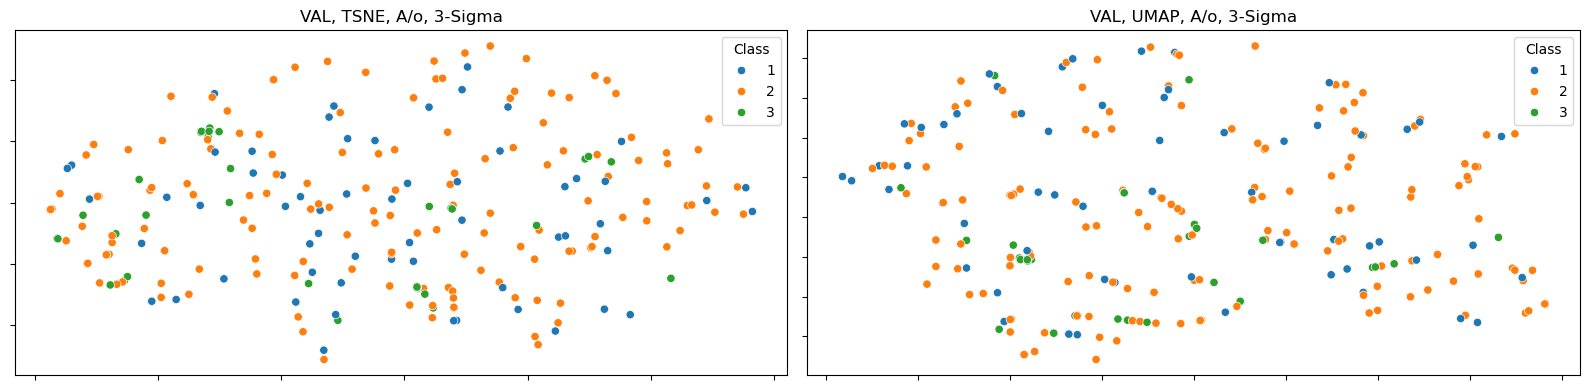

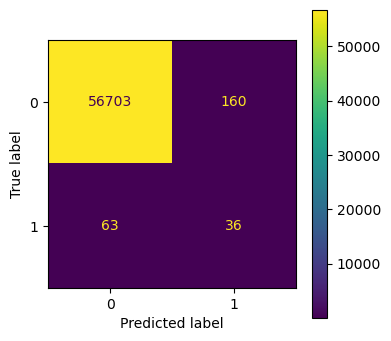

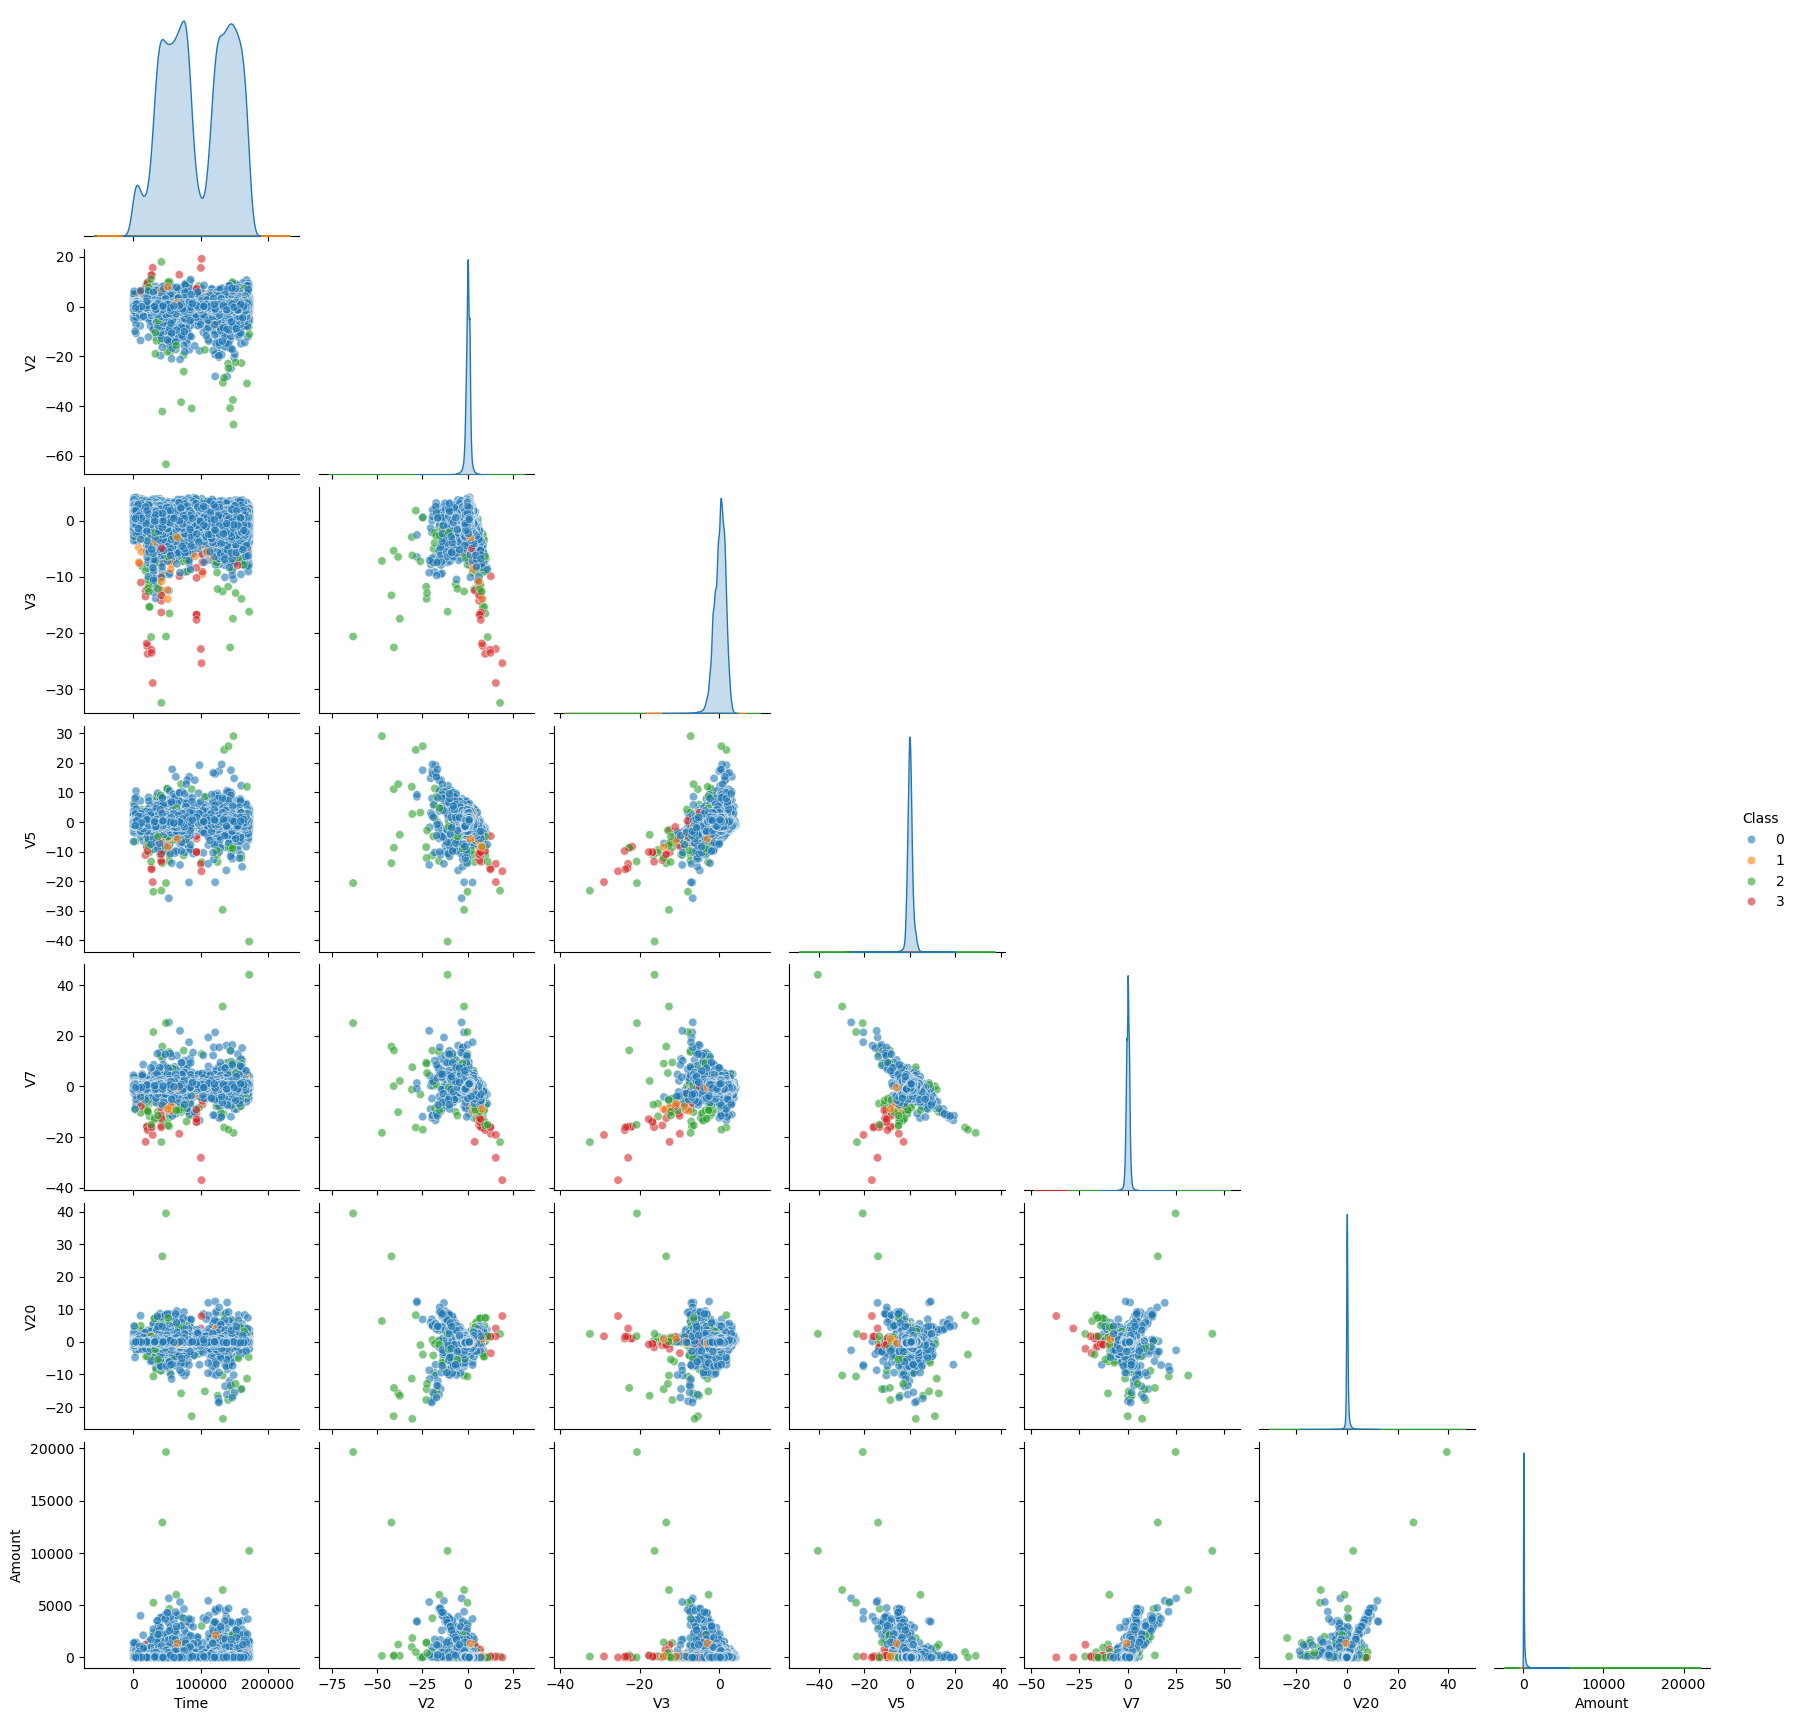

In [ ]:
# Признаки без трансформации
# X_train_three_sigma = X_train
# X_val_three_sigma = X_val

# Приведение данных к нормальному распределению:

# через QuantileTransformer
three_sigma_normal_transformer = QuantileTransformer(output_distribution='normal', random_state=12)
three_sigma_normal_transformer.fit(X_train)
X_train_three_sigma = pd.DataFrame(three_sigma_normal_transformer.transform(X_train), index=X_train.index, columns=df.columns)
X_val_three_sigma = pd.DataFrame(three_sigma_normal_transformer.transform(X_val), index=X_val.index, columns=df.columns)

# через PowerTransformer
# three_sigma_normal_transformer = PowerTransformer(method='yeo-johnson')
# three_sigma_normal_transformer.fit(X_train)
# X_train_three_sigma = pd.DataFrame(three_sigma_normal_transformer.transform(X_train), index=X_train.index, columns=df.columns)
# X_val_three_sigma = pd.DataFrame(three_sigma_normal_transformer.transform(X_val), index=X_val.index, columns=df.columns)

# Работа с моделью
param_grid = {'sigmas': np.arange(3,6,0.2)}
three_sigma_anomalies = cv_processing(ThreeSigmaOutliers(), param_grid, X_train=X_train_three_sigma, y_train=y_train, X_test=X_val_three_sigma)

print_all(SET_VAL, '3-Sigma', X_val, y_val, three_sigma_anomalies, anomalies_only=True)

**Выводы по методу 3-х сигм**: 
1. В наилучем случае при трансформации признаков через QuantileTransformer удалось определить 36 аномалий из исходных 99 (36%) при пороге в 5 сигм, целевая метрика f1 для класса аномалий 0.24.
2.  Без преобразования признаков целевая метрика составила 0.102.
3.  Преобразование признаков к нормальному распределению через QuantileTransformer чувствительно к случайности, без зафиксированного random_state в процессе CV наблюдались лучшие значения f1 на тренировачном наборе от 0.11 до 0.26.
4. Преобразование признаков к нормальному распределению через PowerTransformer показало практически такой же результат, как и без трансформации - f1 0.10

#### Box-plot

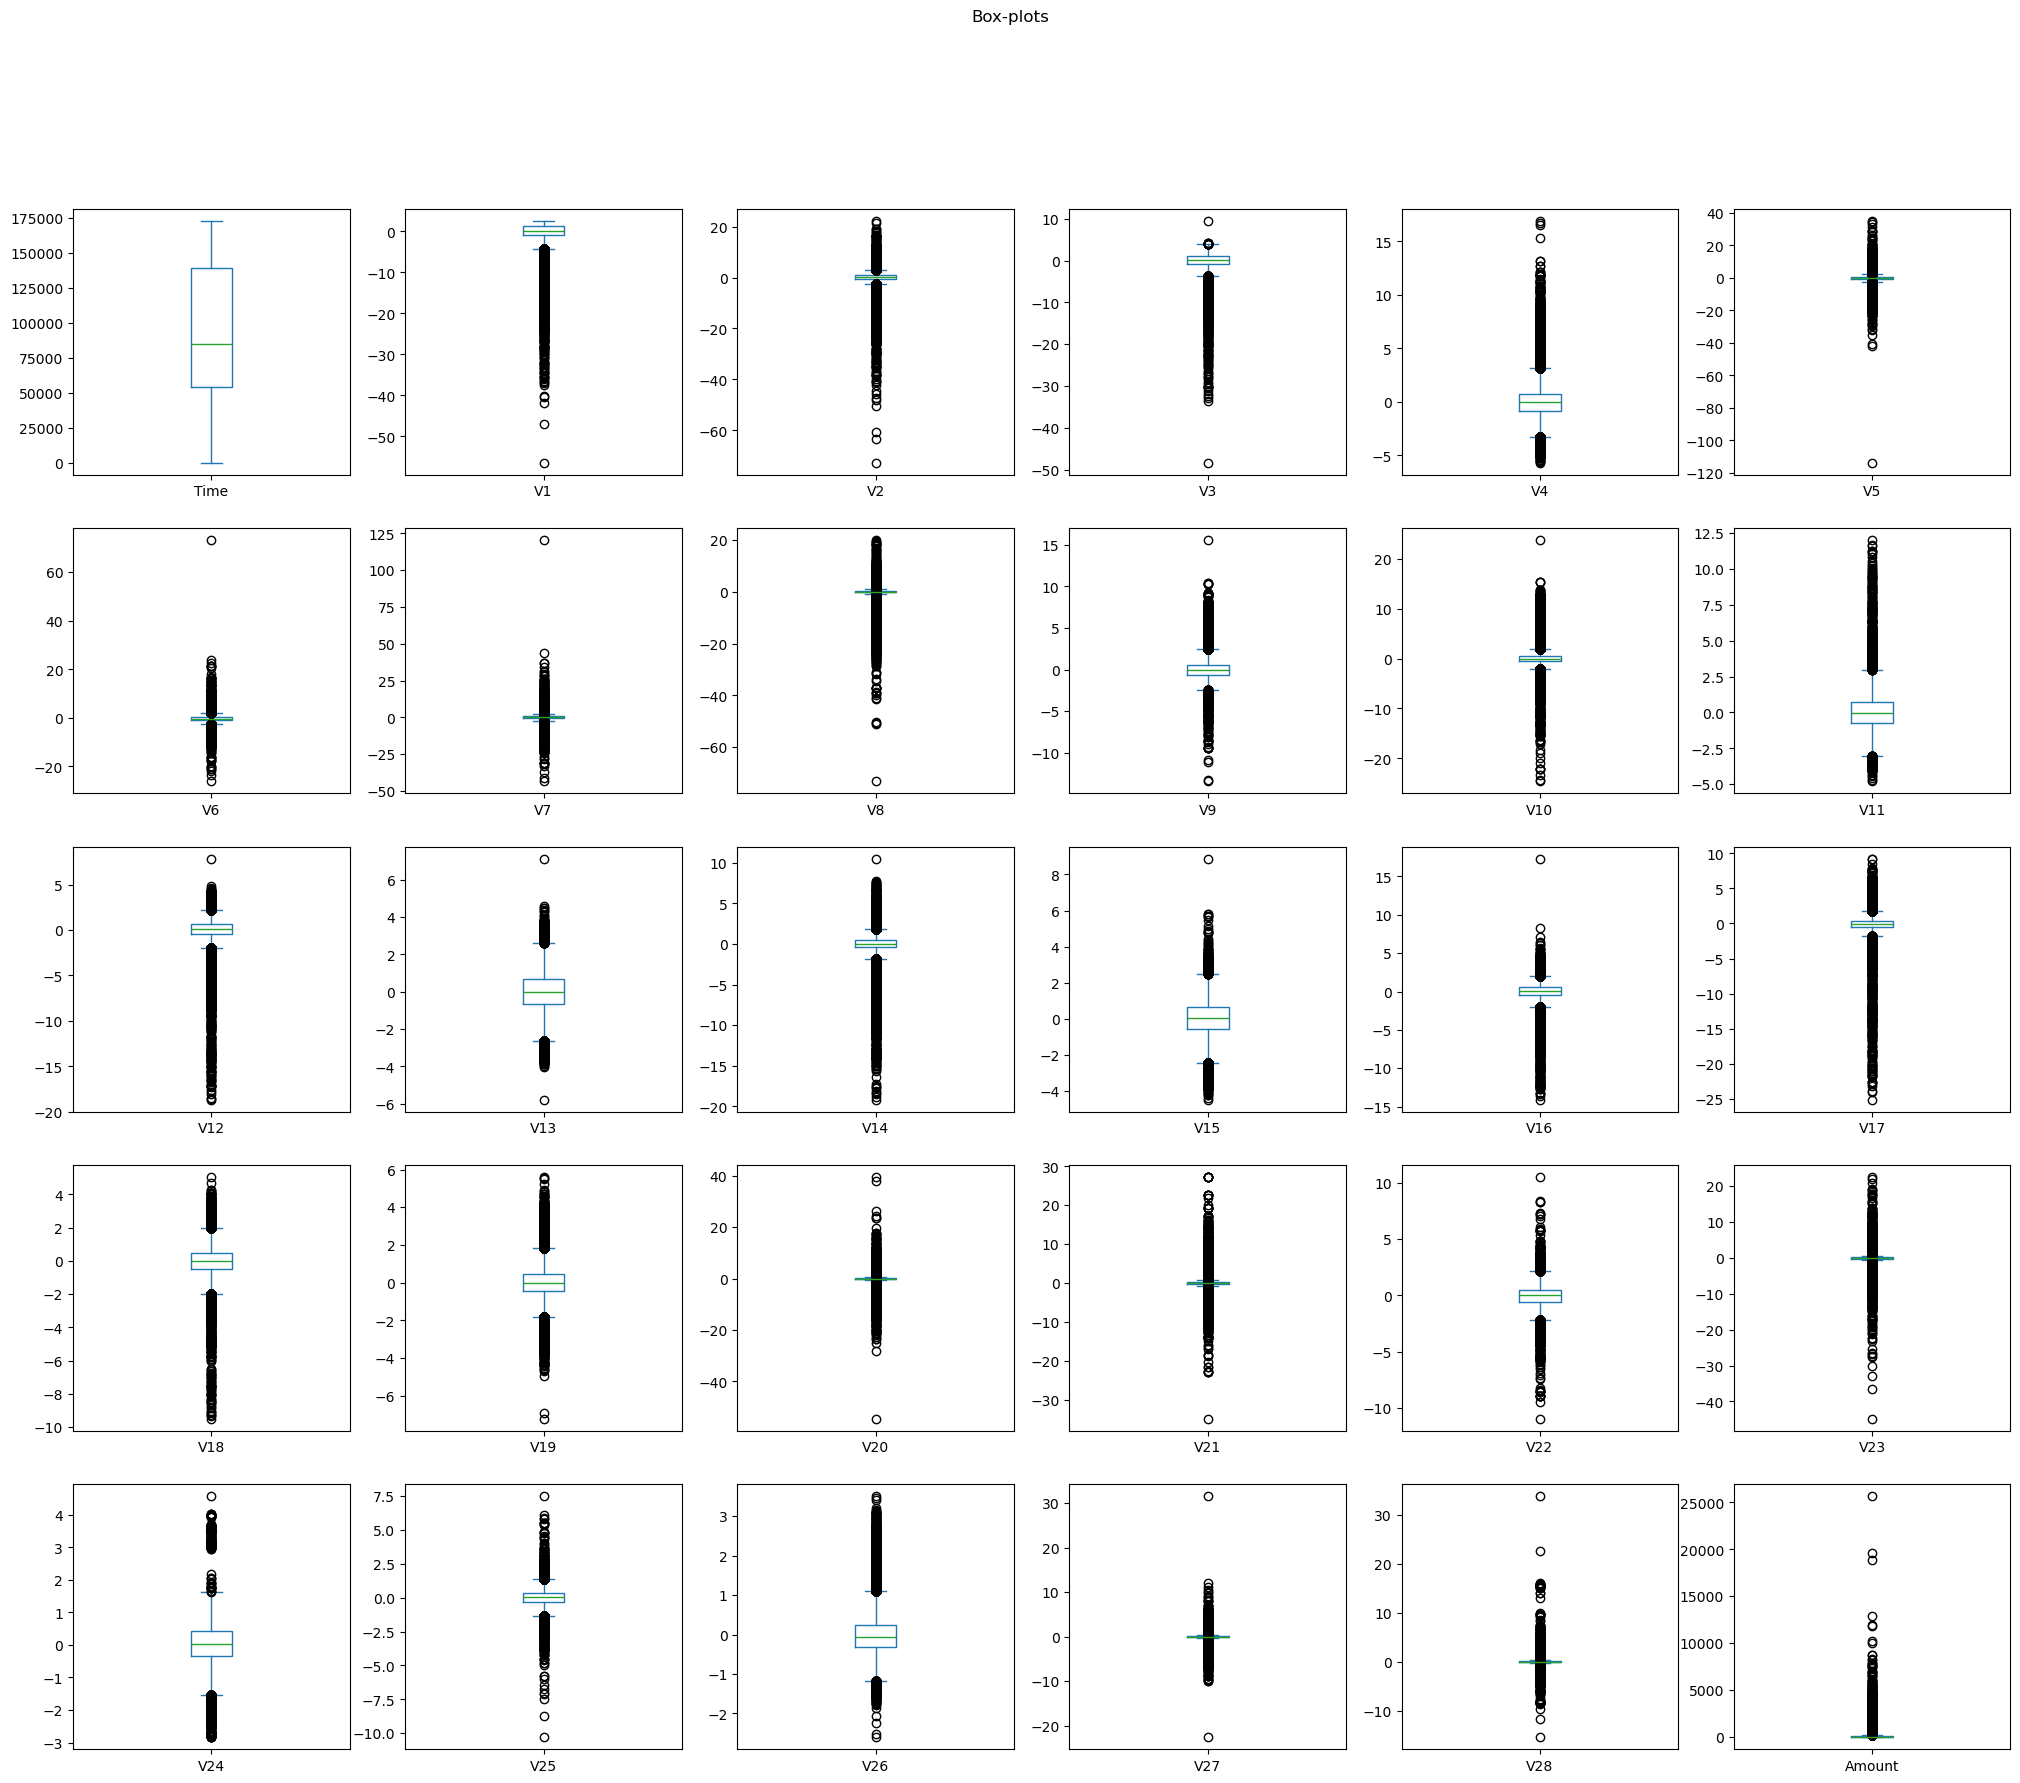

In [ ]:
fig, axes = plt.subplots(5, 6, figsize=(25, 20))
fig.suptitle('Box-plots')

for i, column in enumerate(df.columns):
    ax = axes[i//6][i%6]
    df[column].plot.box(ax=ax)

In [ ]:
class BoxPlotOutliers(BoundsOutliersEstimator):
    """
    -----------
    Parameters:

    - threshold: float
        пороговое смещение от Q1 и Q3
    """
    def __init__(self, threshold=1.5):
        self.threshold = threshold

    def fit(self, X, y=None):
        # Расчет харакетристик перцентилей
        X_agg = X.quantile([0.25, 0.75]).T
        X_agg.columns=['Q1','Q3']
        X_agg['IQR'] = X_agg['Q3'] - X_agg['Q1']
            
        # Рассчет границ для каждого столбца
        self.bounds = pd.concat([
            X_agg['Q3'] + self.threshold * X_agg['IQR'], 
            X_agg['Q1'] - self.threshold * X_agg['IQR']], 
            axis=1, 
            keys=['up_bound', 'low_bound']
            )

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшие параметры CV: {'threshold': np.float64(18.199999999999996)}
Лучшая метрика обучения CV: 0.058893540846612115
Метрики классификации:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56863
           1       0.03      0.18      0.05        99

    accuracy                           0.99     56962
   macro avg       0.51      0.59      0.52     56962
weighted avg       1.00      0.99      0.99     56962


    Истинные аномалии: 
        Количество: 99
        Процент:   0.17%
    Предсказанные аномалии:
        Количество: 676
        Процент:   1.19%


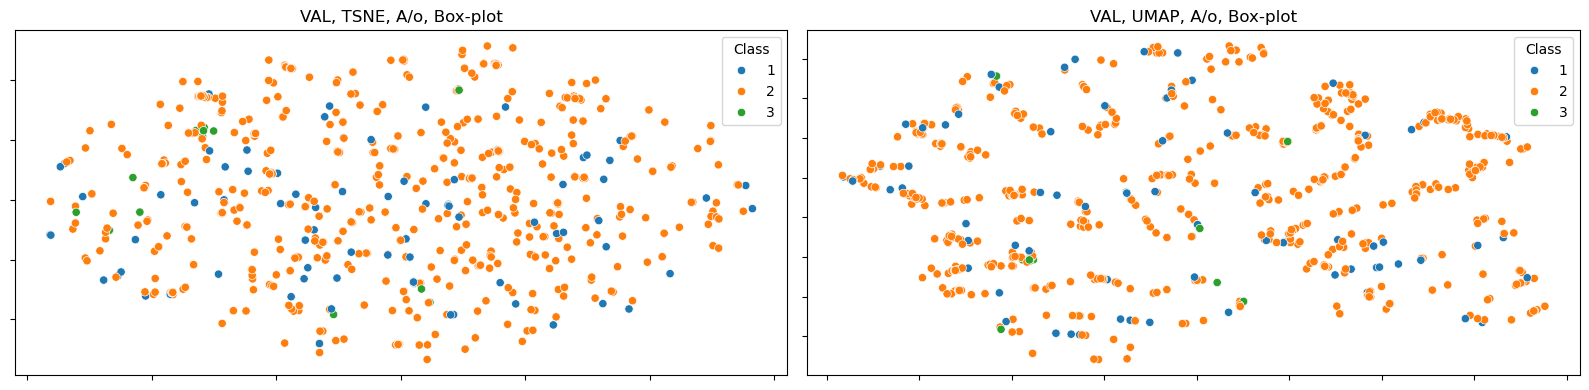

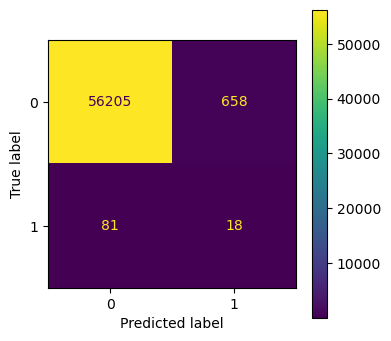

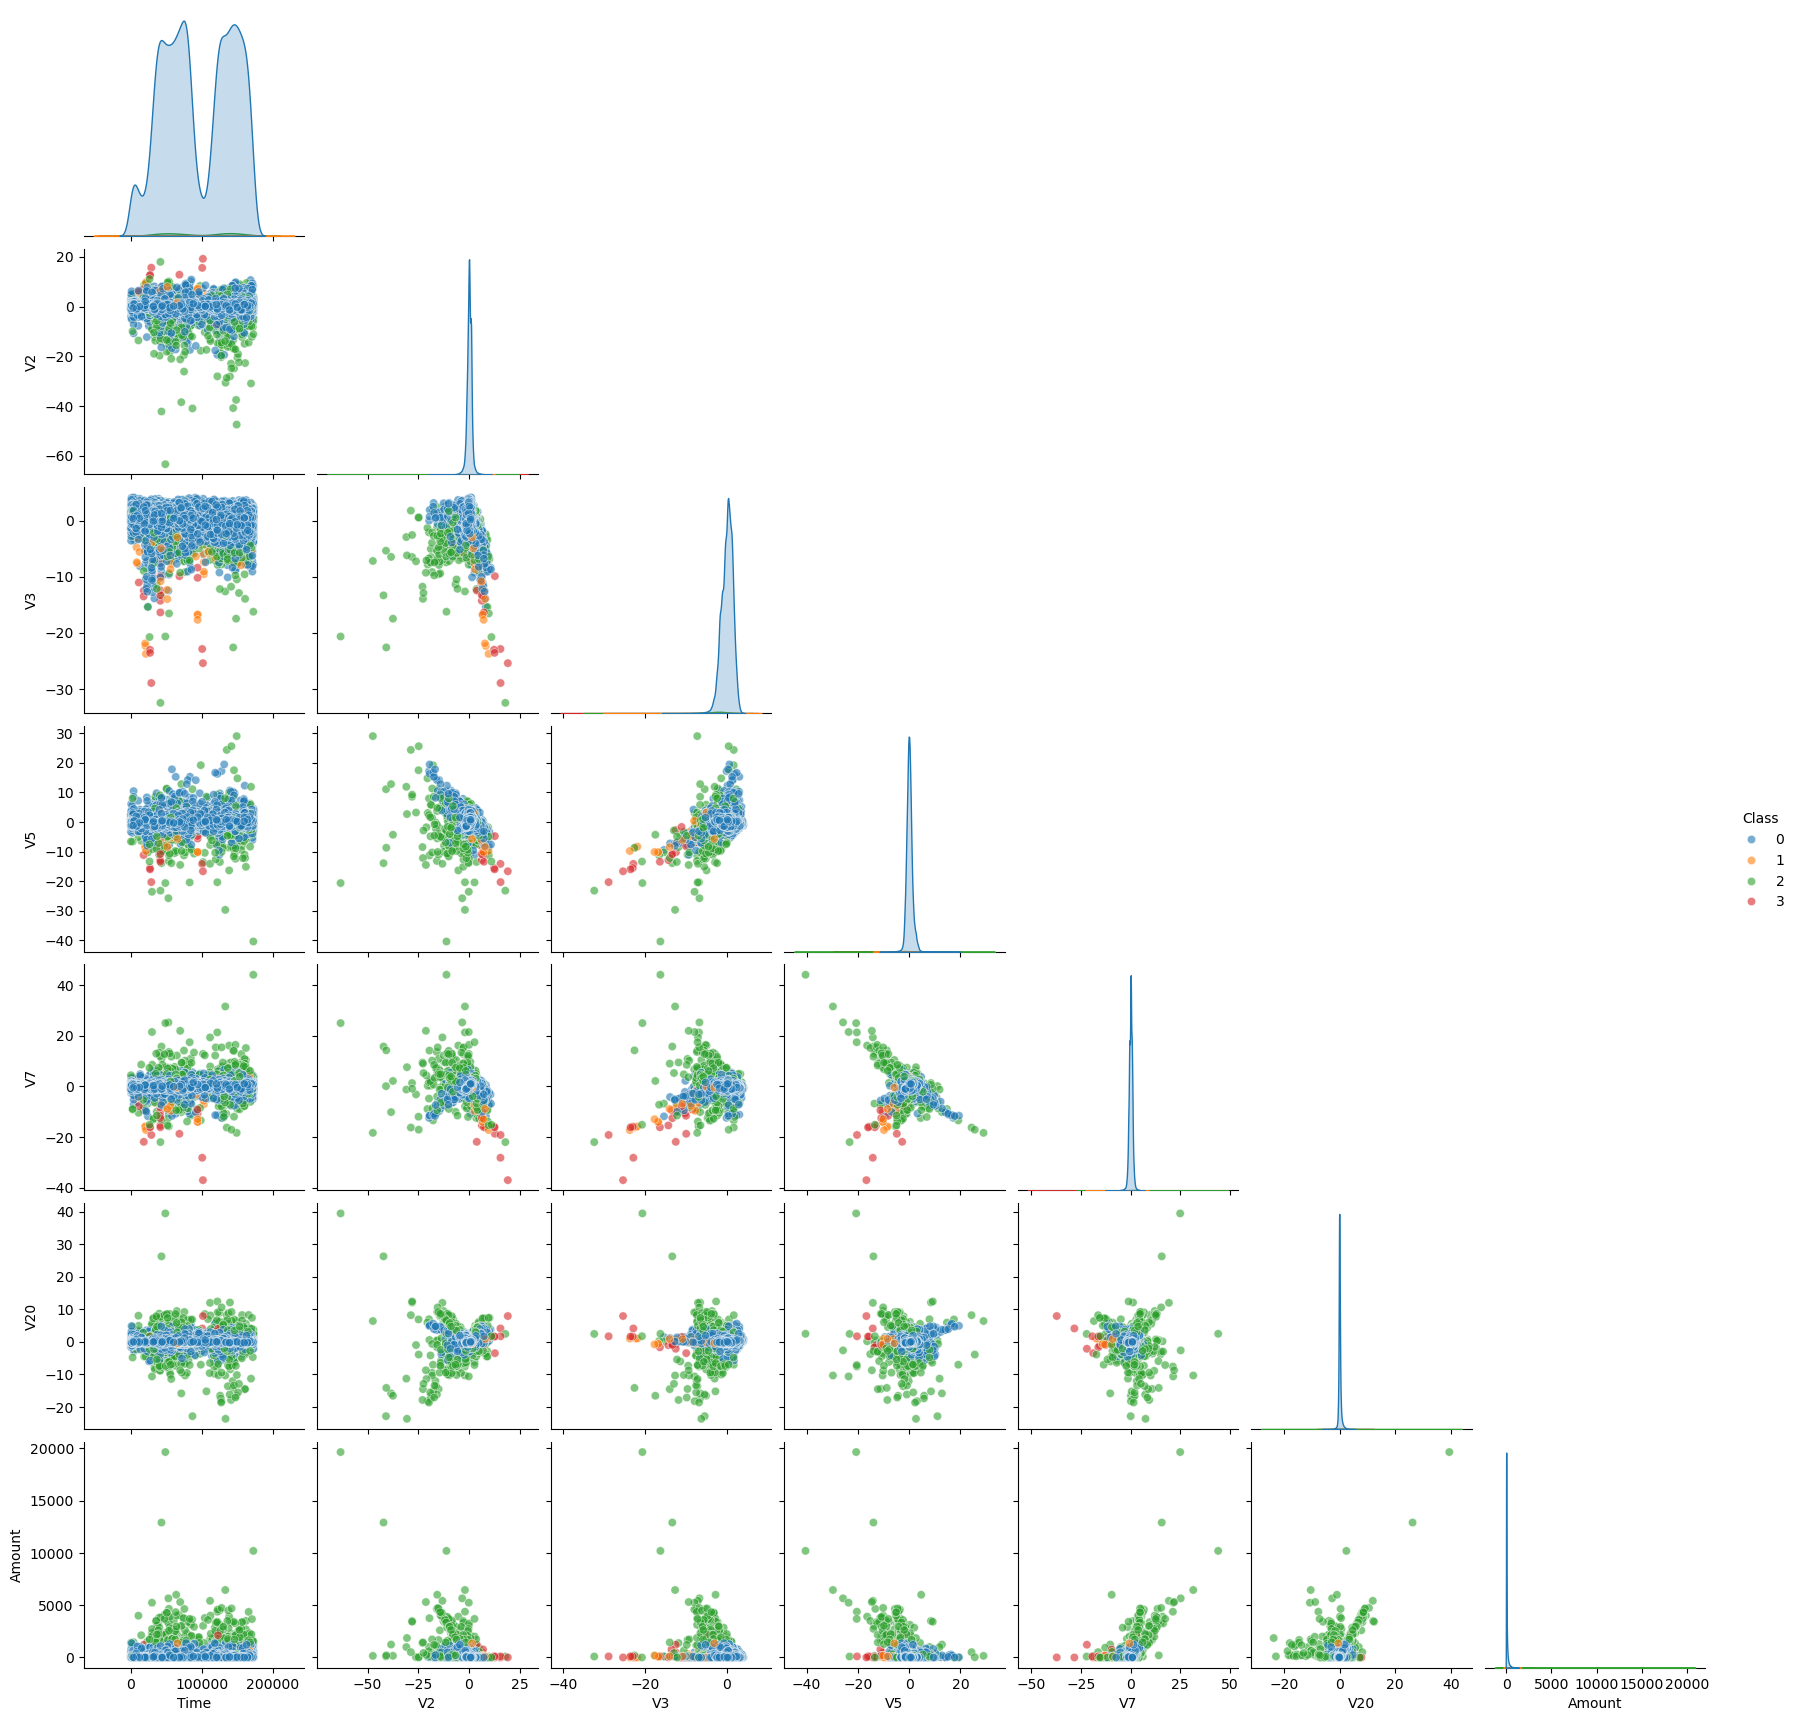

In [ ]:
X_train_box_plot = X_train
X_val_box_plot = X_val

param_grid = {'threshold': np.arange(17,19,0.2)}
box_plot_anomalies = cv_processing(BoxPlotOutliers(), param_grid, X_train=X_train_box_plot, y_train=y_train, X_test=X_val_box_plot)

print_all(SET_VAL, 'Box-plot', X_val, y_val, box_plot_anomalies, anomalies_only=True)

**Вывод по методу ящика с усами**: 
1. В наилучем случае удалось определить 18 аномалий из исходных 99 (18%) при пороге в 18.2 IQR, целевая метрика f1 для класса аномалий 0.05.
2. Алгоритм работает хуже чем метод 3-х сигм даже без преобразования.

#### Distance-based

In [ ]:
from scipy.spatial.distance import cdist

class DistanceOutliers(BaseOutliersEstimator):
    """
    -----------
    Parameters:

    - metric: string, default - euclidean
        metric to use for distance calculation (see scipy.spatial.distance.cdist)

    - percentile: float in range [0, 100]
        hyperparameter which sets the threshold for anomalies
    """
    def __init__(self, metric='euclidean', percentile=90):
        self.metric = metric
        self.percentile = percentile

    def fit(self, X, y=None):
        # Расчет центроида по каждой фиче
        self.centroid = np.mean(X, axis=0).values.reshape(-1, 1).T
        # Расчет расстояний от центроида до каждого наблюдения
        distances_train = cdist(self.centroid, X, metric=self.metric).reshape(-1)
        # Определение предельного расстояния, при превышении которого считать наблюдение аномальным
        self.threshold = np.percentile(distances_train, self.percentile)

    def predict(self, X):
        distances = cdist(self.centroid, X, metric=self.metric).reshape(-1)
        predictions = (distances > self.threshold).astype(int)
        return predictions

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Лучшие параметры CV: {'metric': 'mahalanobis', 'percentile': np.float64(99.60000000000007)}
Лучшая метрика обучения CV: 0.22165298930186839
Метрики классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.15      0.38      0.22        99

    accuracy                           1.00     56962
   macro avg       0.58      0.69      0.61     56962
weighted avg       1.00      1.00      1.00     56962


    Истинные аномалии: 
        Количество: 99
        Процент:   0.17%
    Предсказанные аномалии:
        Количество: 250
        Процент:   0.44%


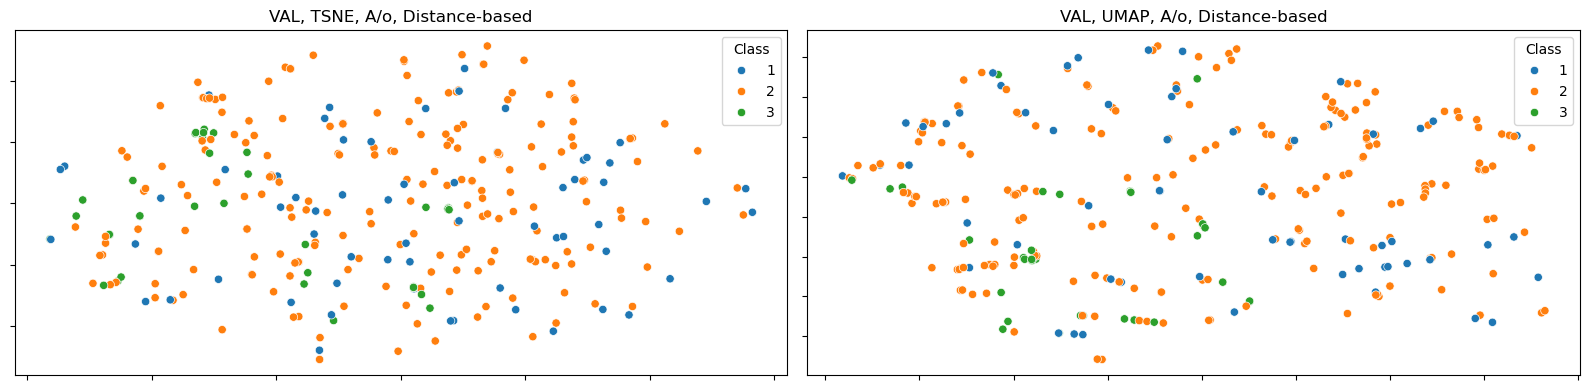

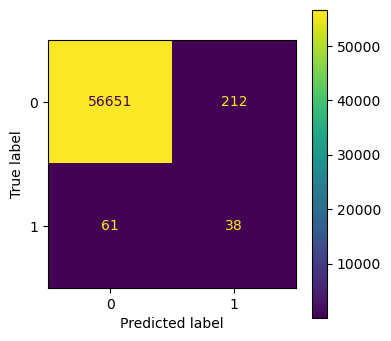

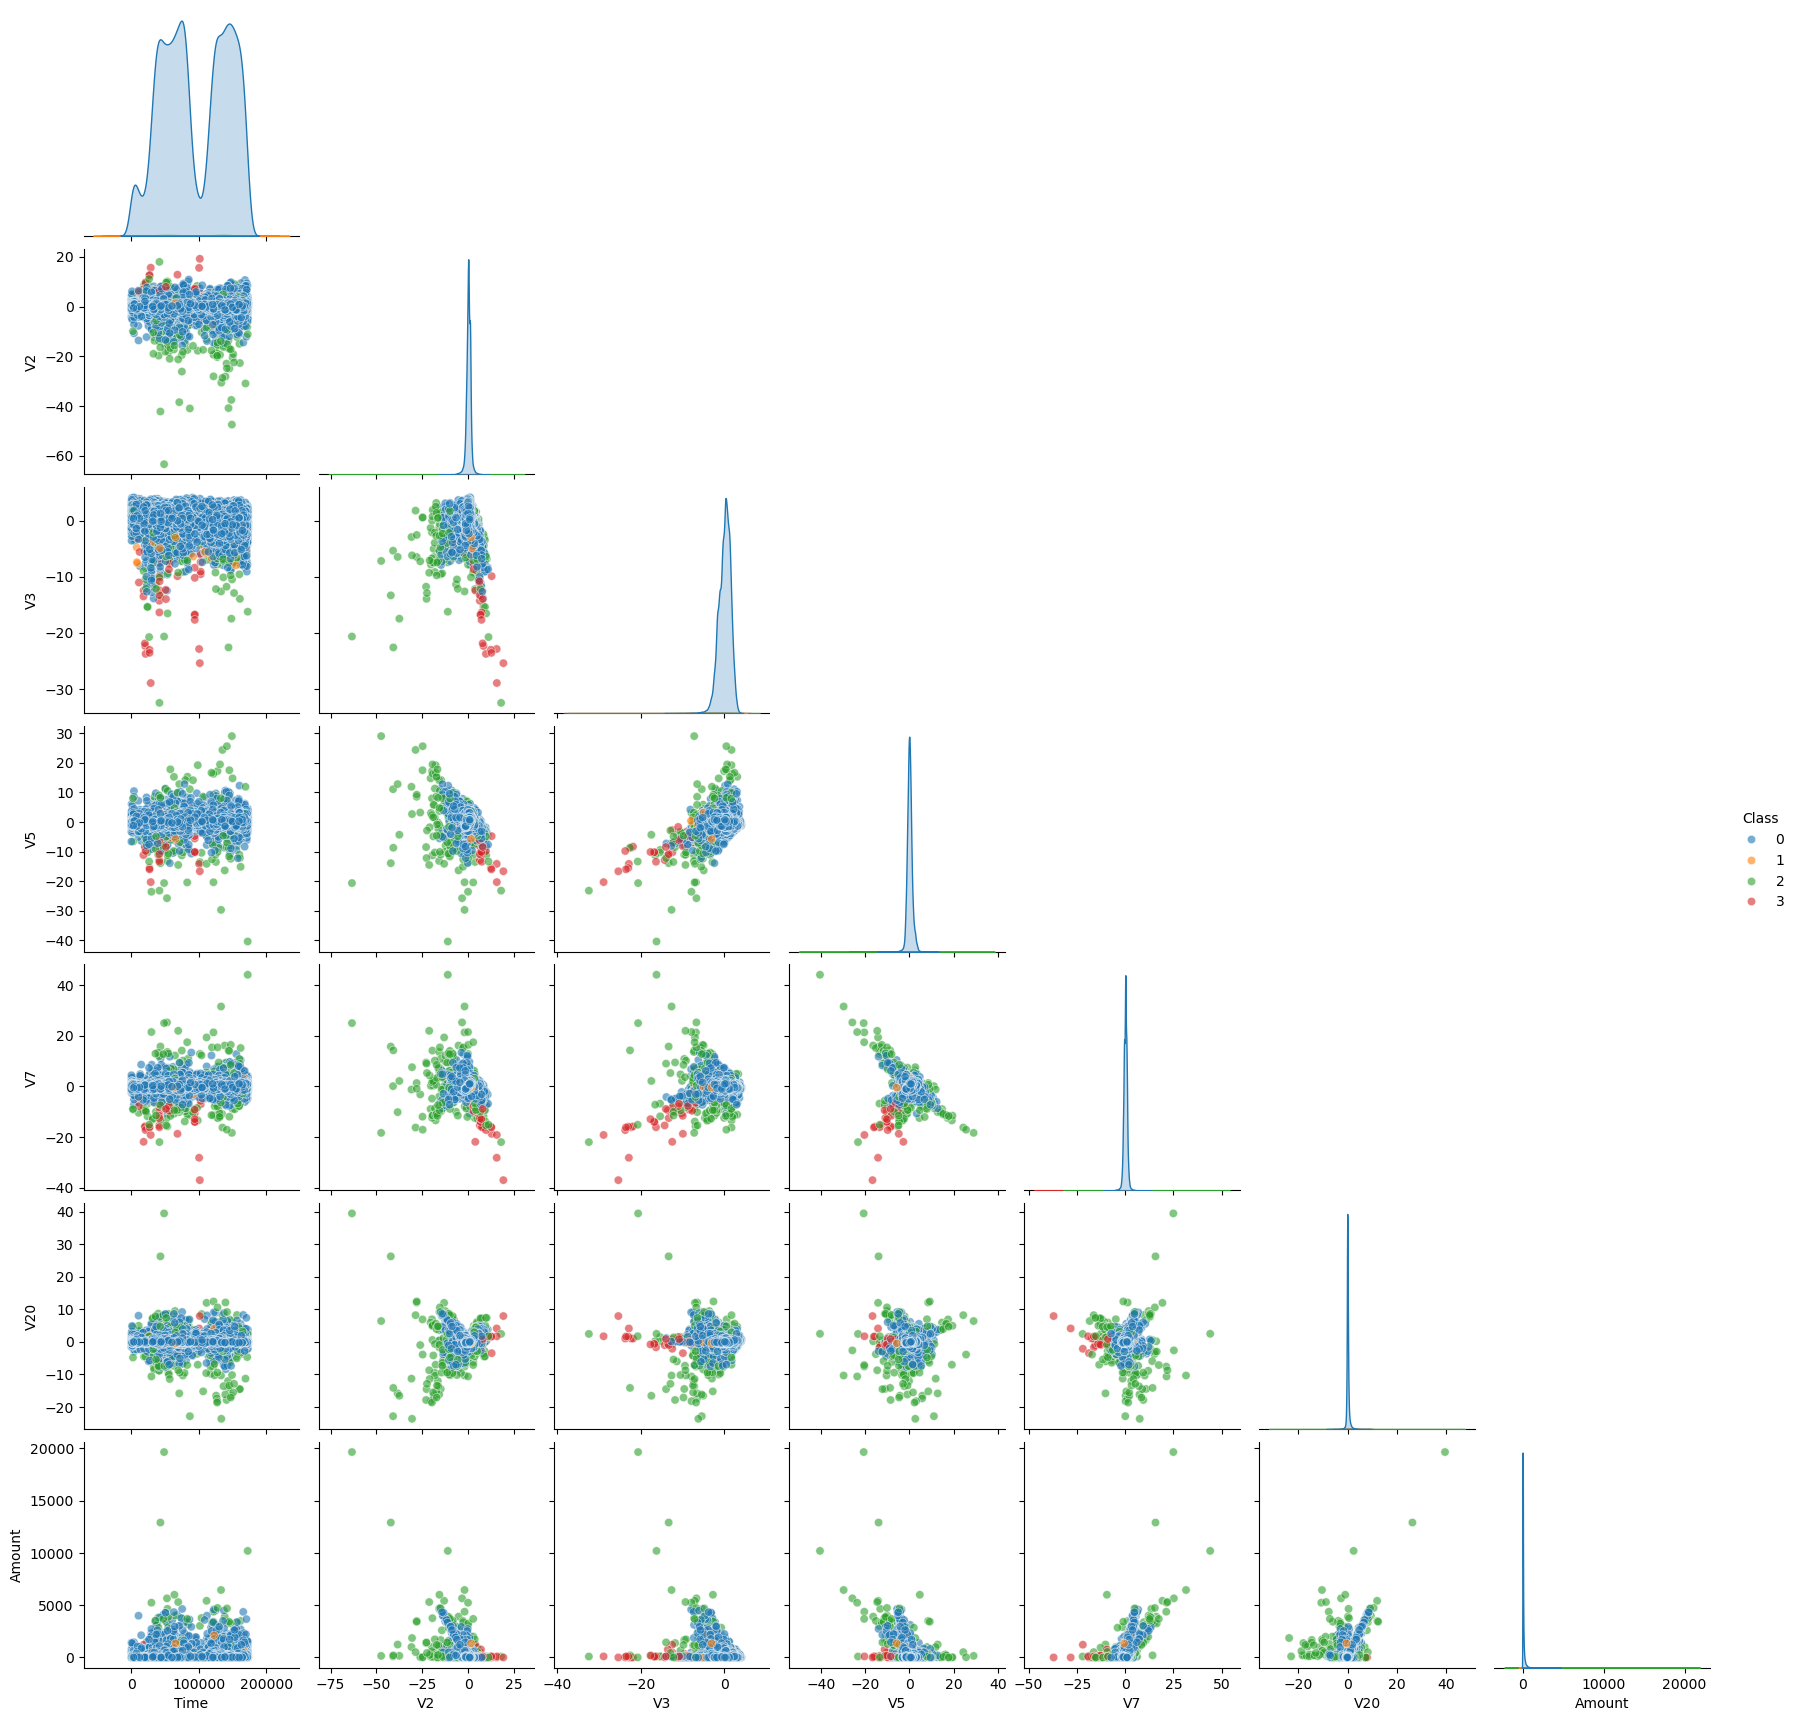

In [ ]:
# Нормализация признаков
distance_scaler = RobustScaler()
distance_scaler.fit(X_train)
X_train_distance = pd.DataFrame(distance_scaler.transform(X_train), index=X_train.index, columns=df.columns)
X_val_distance = pd.DataFrame(distance_scaler.transform(X_val), index=X_val.index, columns=df.columns)

# Работа с моделью
param_grid = {'percentile': np.arange(95,100,0.2), 'metric': ['cosine', 'euclidean', 'mahalanobis']}
distance_anomalies = cv_processing(DistanceOutliers(), param_grid, X_train=X_train_distance, y_train=y_train, X_test=X_val_distance)

print_all(SET_VAL, 'Distance-based', X_val, y_val, distance_anomalies, anomalies_only=True)

**Выводы по методу, основанному на расстоянии**: 
1. В наилучем случае удалось определить 38 аномалий из исходных 99 (38%) при пороговом значении расстояния от центра в 99.6% и методе расчета расстояния mahalanobis, целевая метрика f1 для класса аномалий 0.22.
2. Алгоритм оказался чувствительным к методу расчета расстояния, для euclidean не удалось получить f1 выше 0.13.

#### DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN, OPTICS

class DBSCANOutliers(BaseOutliersEstimator):
    """
    -----------
    Parameters:

    - eps: float
        радиус окрестности точки для определения её соседей
    """
    def __init__(self, eps=0.01, min_samples=5):
        self.eps = eps
        self.min_samples = min_samples

    def fit(self, X, y=None):
        # Метод выучивания параметров для данной модели не имеет смысла
        pass

    def predict(self, X):
        # Не удалось вместить в ОЗУ даже валидационный набор для DBSCAN
        # model = DBSCAN(eps=self.eps).fit(X)
        model = OPTICS(eps=self.eps, min_samples=self.min_samples, cluster_method='dbscan').fit(X)
        labels = model.labels_
        return np.array([1 if label == -1 else 0 for label in labels])

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Лучшие параметры CV: {'eps': np.float64(9.2)}
Лучшая метрика обучения CV: 0.15570337750670254
Метрики классификации:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56863
           1       0.10      0.38      0.16        99

    accuracy                           0.99     56962
   macro avg       0.55      0.69      0.58     56962
weighted avg       1.00      0.99      0.99     56962


    Истинные аномалии: 
        Количество: 99
        Процент:   0.17%
    Предсказанные аномалии:
        Количество: 385
        Процент:   0.68%


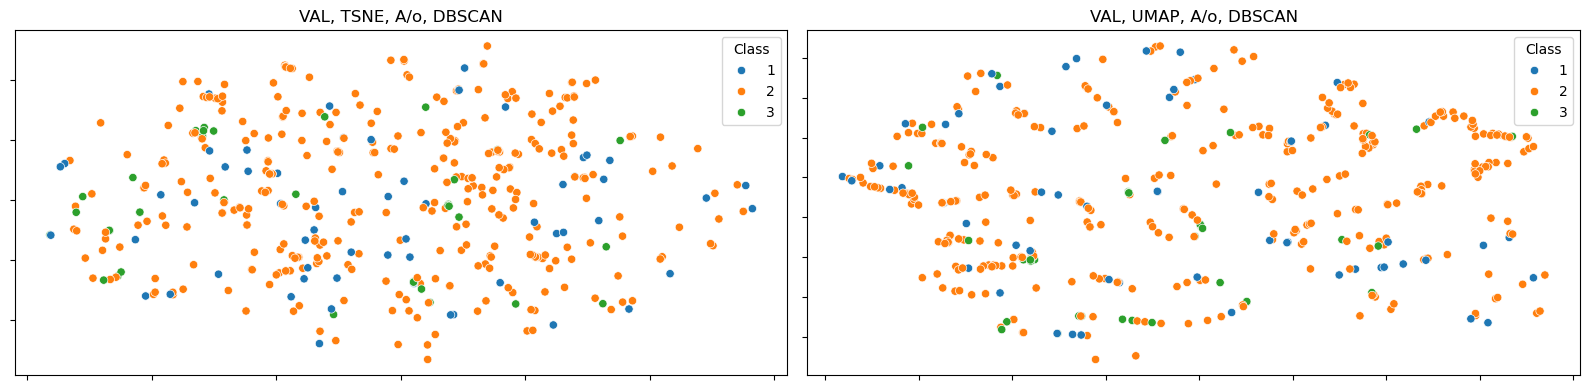

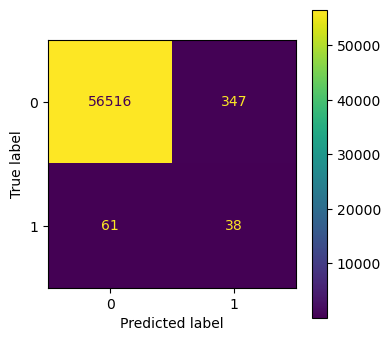

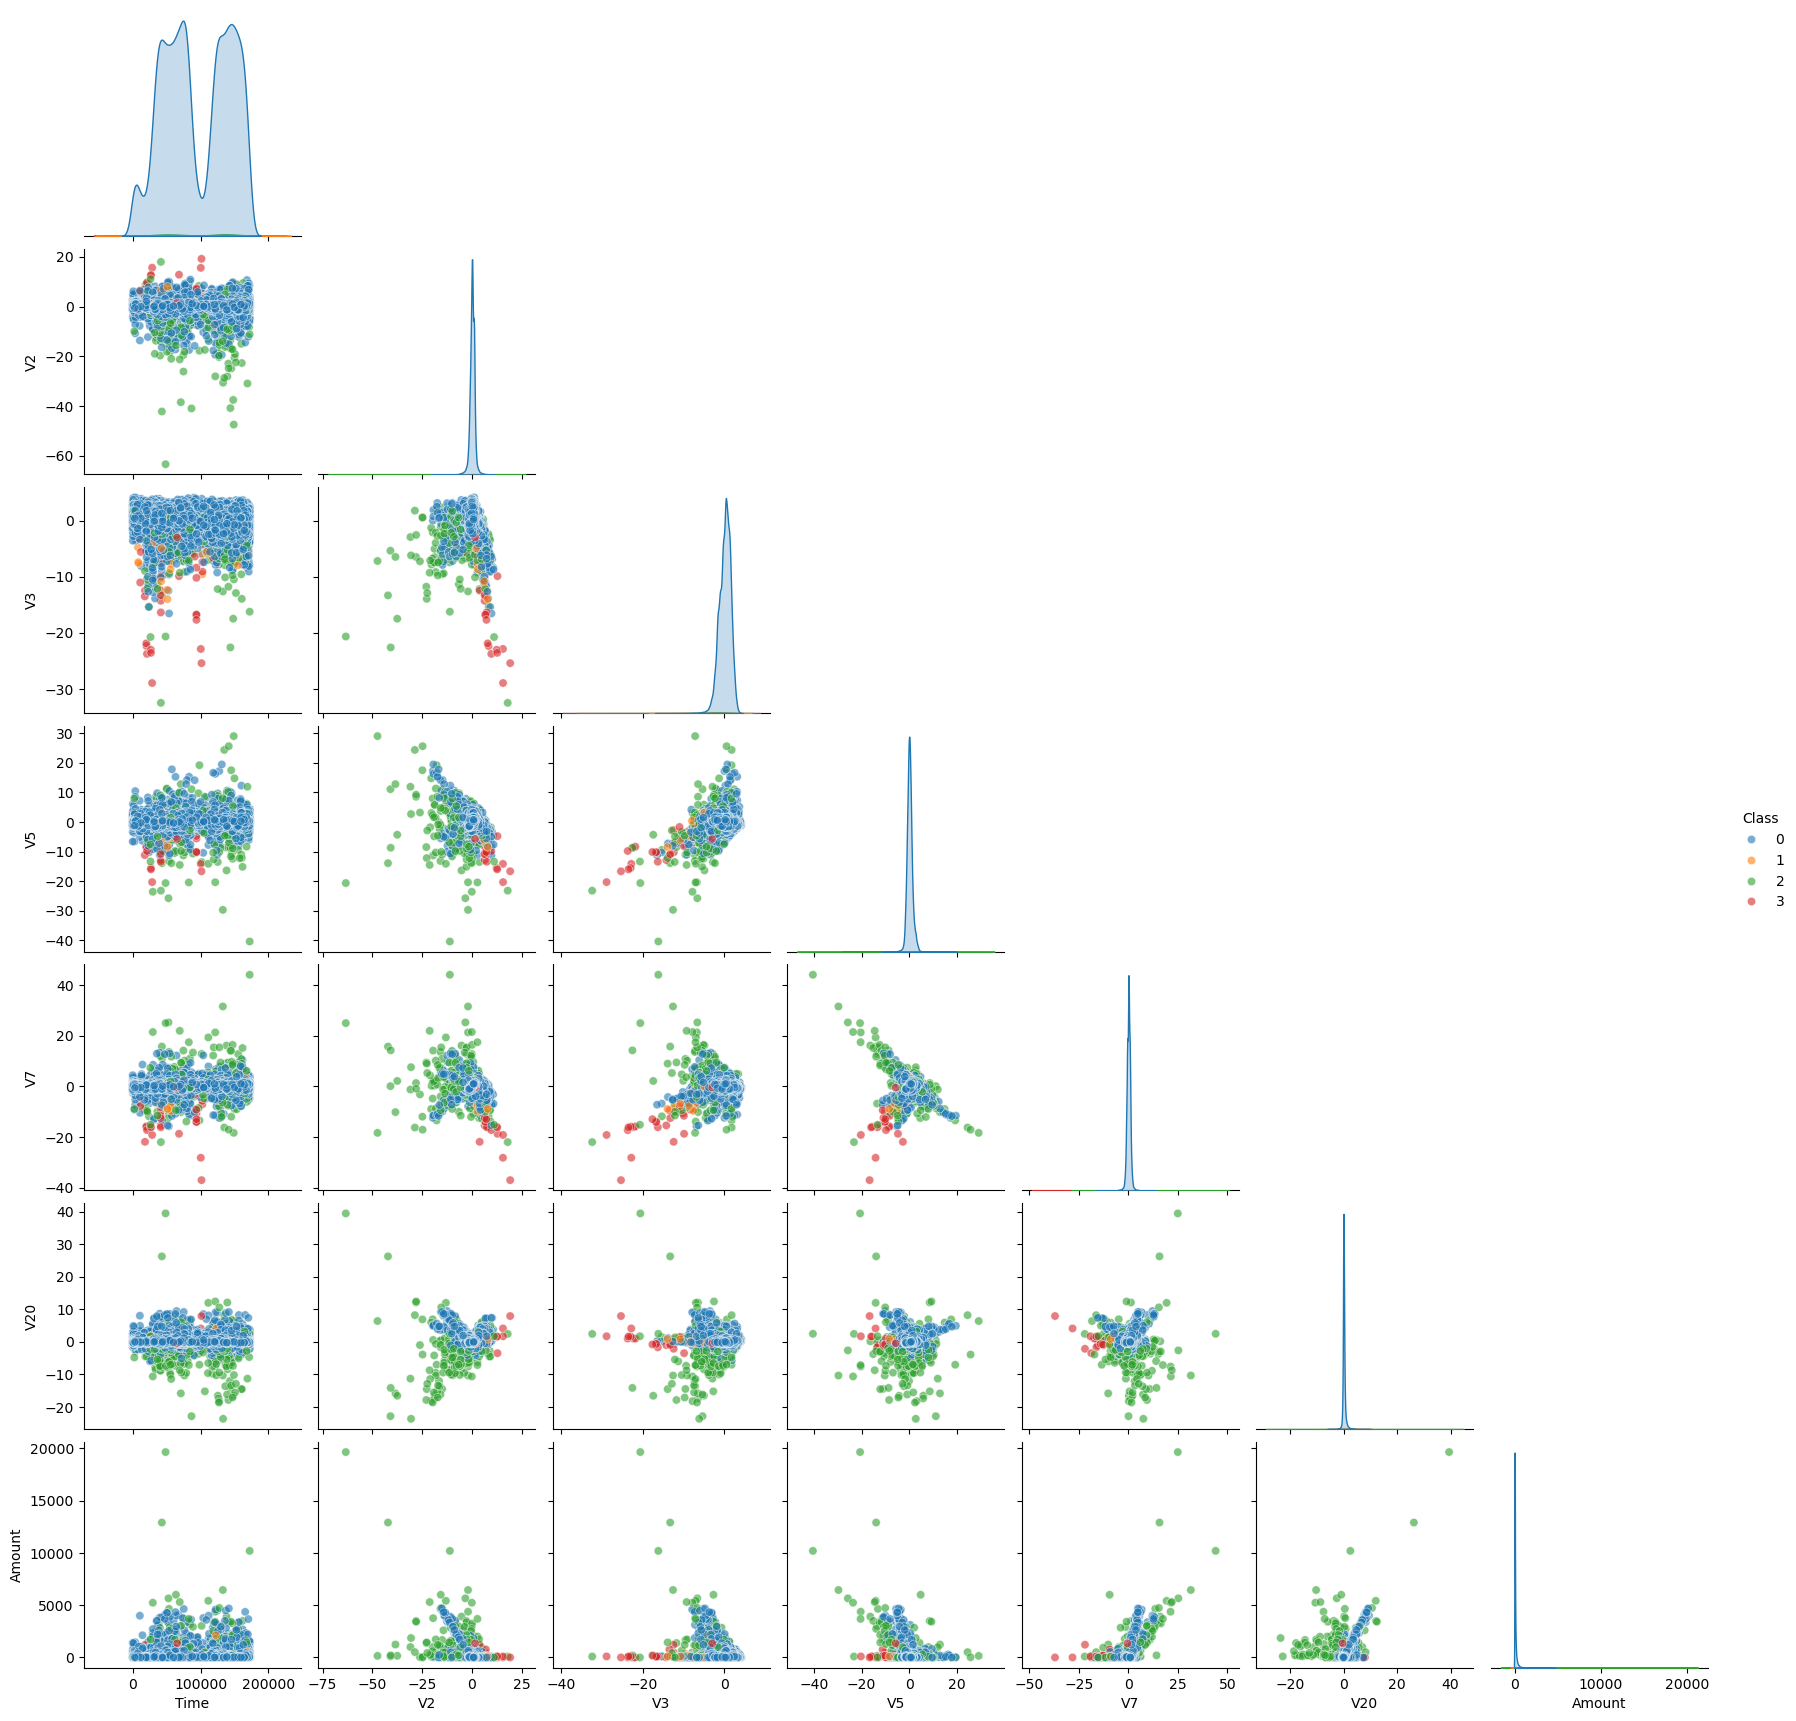

In [ ]:
# Нормализация признаков
dbscan_scaler = RobustScaler()
dbscan_scaler.fit(X_train)
X_train_dbscan = pd.DataFrame(dbscan_scaler.transform(X_train), index=X_train.index, columns=df.columns)
X_val_dbscan = pd.DataFrame(dbscan_scaler.transform(X_val), index=X_val.index, columns=df.columns)

# Работа с моделью
param_grid = {'eps': np.arange(9.1, 9.4, 0.1)}
dbscan_anomalies = cv_processing(DBSCANOutliers(), param_grid, X_train=X_train_dbscan, y_train=y_train, X_test=X_val_dbscan, verbose=1)

print_all(SET_VAL, 'DBSCAN', X_val, y_val, dbscan_anomalies, anomalies_only=True)

**Выводы по методу DBSCAN**:
1. В наилучем случае удалось определить 38 аномалий из исходных 99 (38%) при радиусе окрестности 9.2, целевая метрика f1 для класса аномалий 0.16.
2. Алгоритм, реализованный в классе DBSCAN не справился с набором данных 57k x 30 при 22 свободных Гб ОЗУ.

#### One-Class SVM

In [ ]:
from sklearn.svm import OneClassSVM

class OCSVMOutliers(BaseOutliersEstimator):
    """
    -----------
    Parameters:

    - nu: float
        искомый процент аномалий
    - kernel
        тип ядро 
    """
    def __init__(self, nu=0.05, kernel='rbf'):
        self.nu = nu
        self.kernel = kernel

    def fit(self, X, y=None):
        self.model = OneClassSVM(nu=self.nu, kernel=self.kernel, gamma='auto')
        self.model.fit(X)

    def predict(self, X):
        svm_outliers = self.model.predict(X)
        return np.array([1 if label == -1 else 0 for label in svm_outliers])

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры CV: {'kernel': 'sigmoid', 'nu': np.float64(0.0019)}
Лучшая метрика обучения CV: 0.08922819748582425
Метрики классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.14      0.15      0.14        99

    accuracy                           1.00     56962
   macro avg       0.57      0.57      0.57     56962
weighted avg       1.00      1.00      1.00     56962


    Истинные аномалии: 
        Количество: 99
        Процент:   0.17%
    Предсказанные аномалии:
        Количество: 111
        Процент:   0.19%


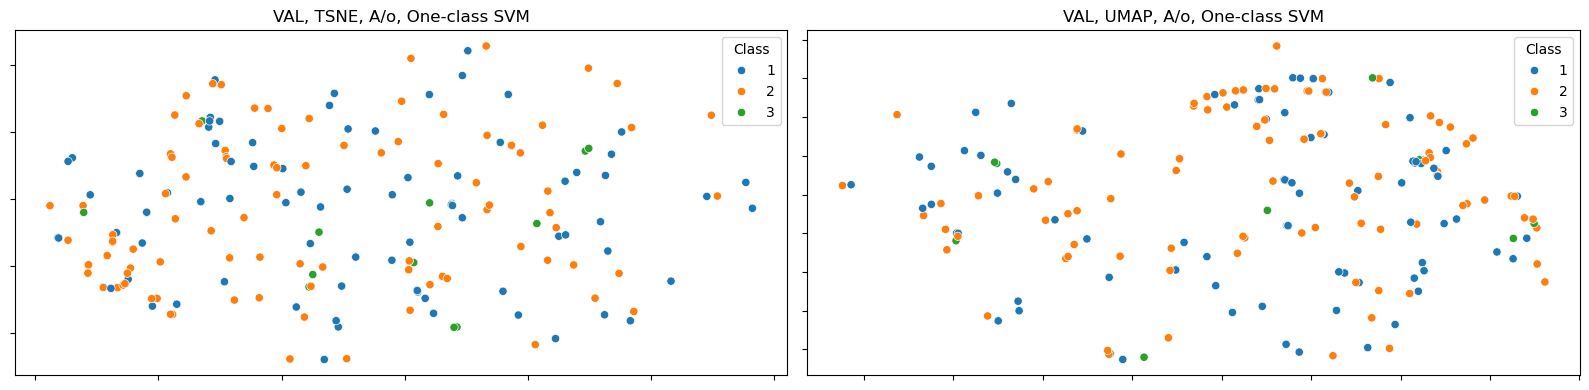

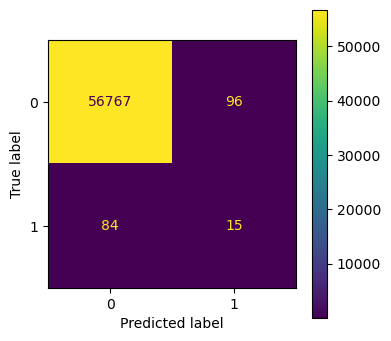

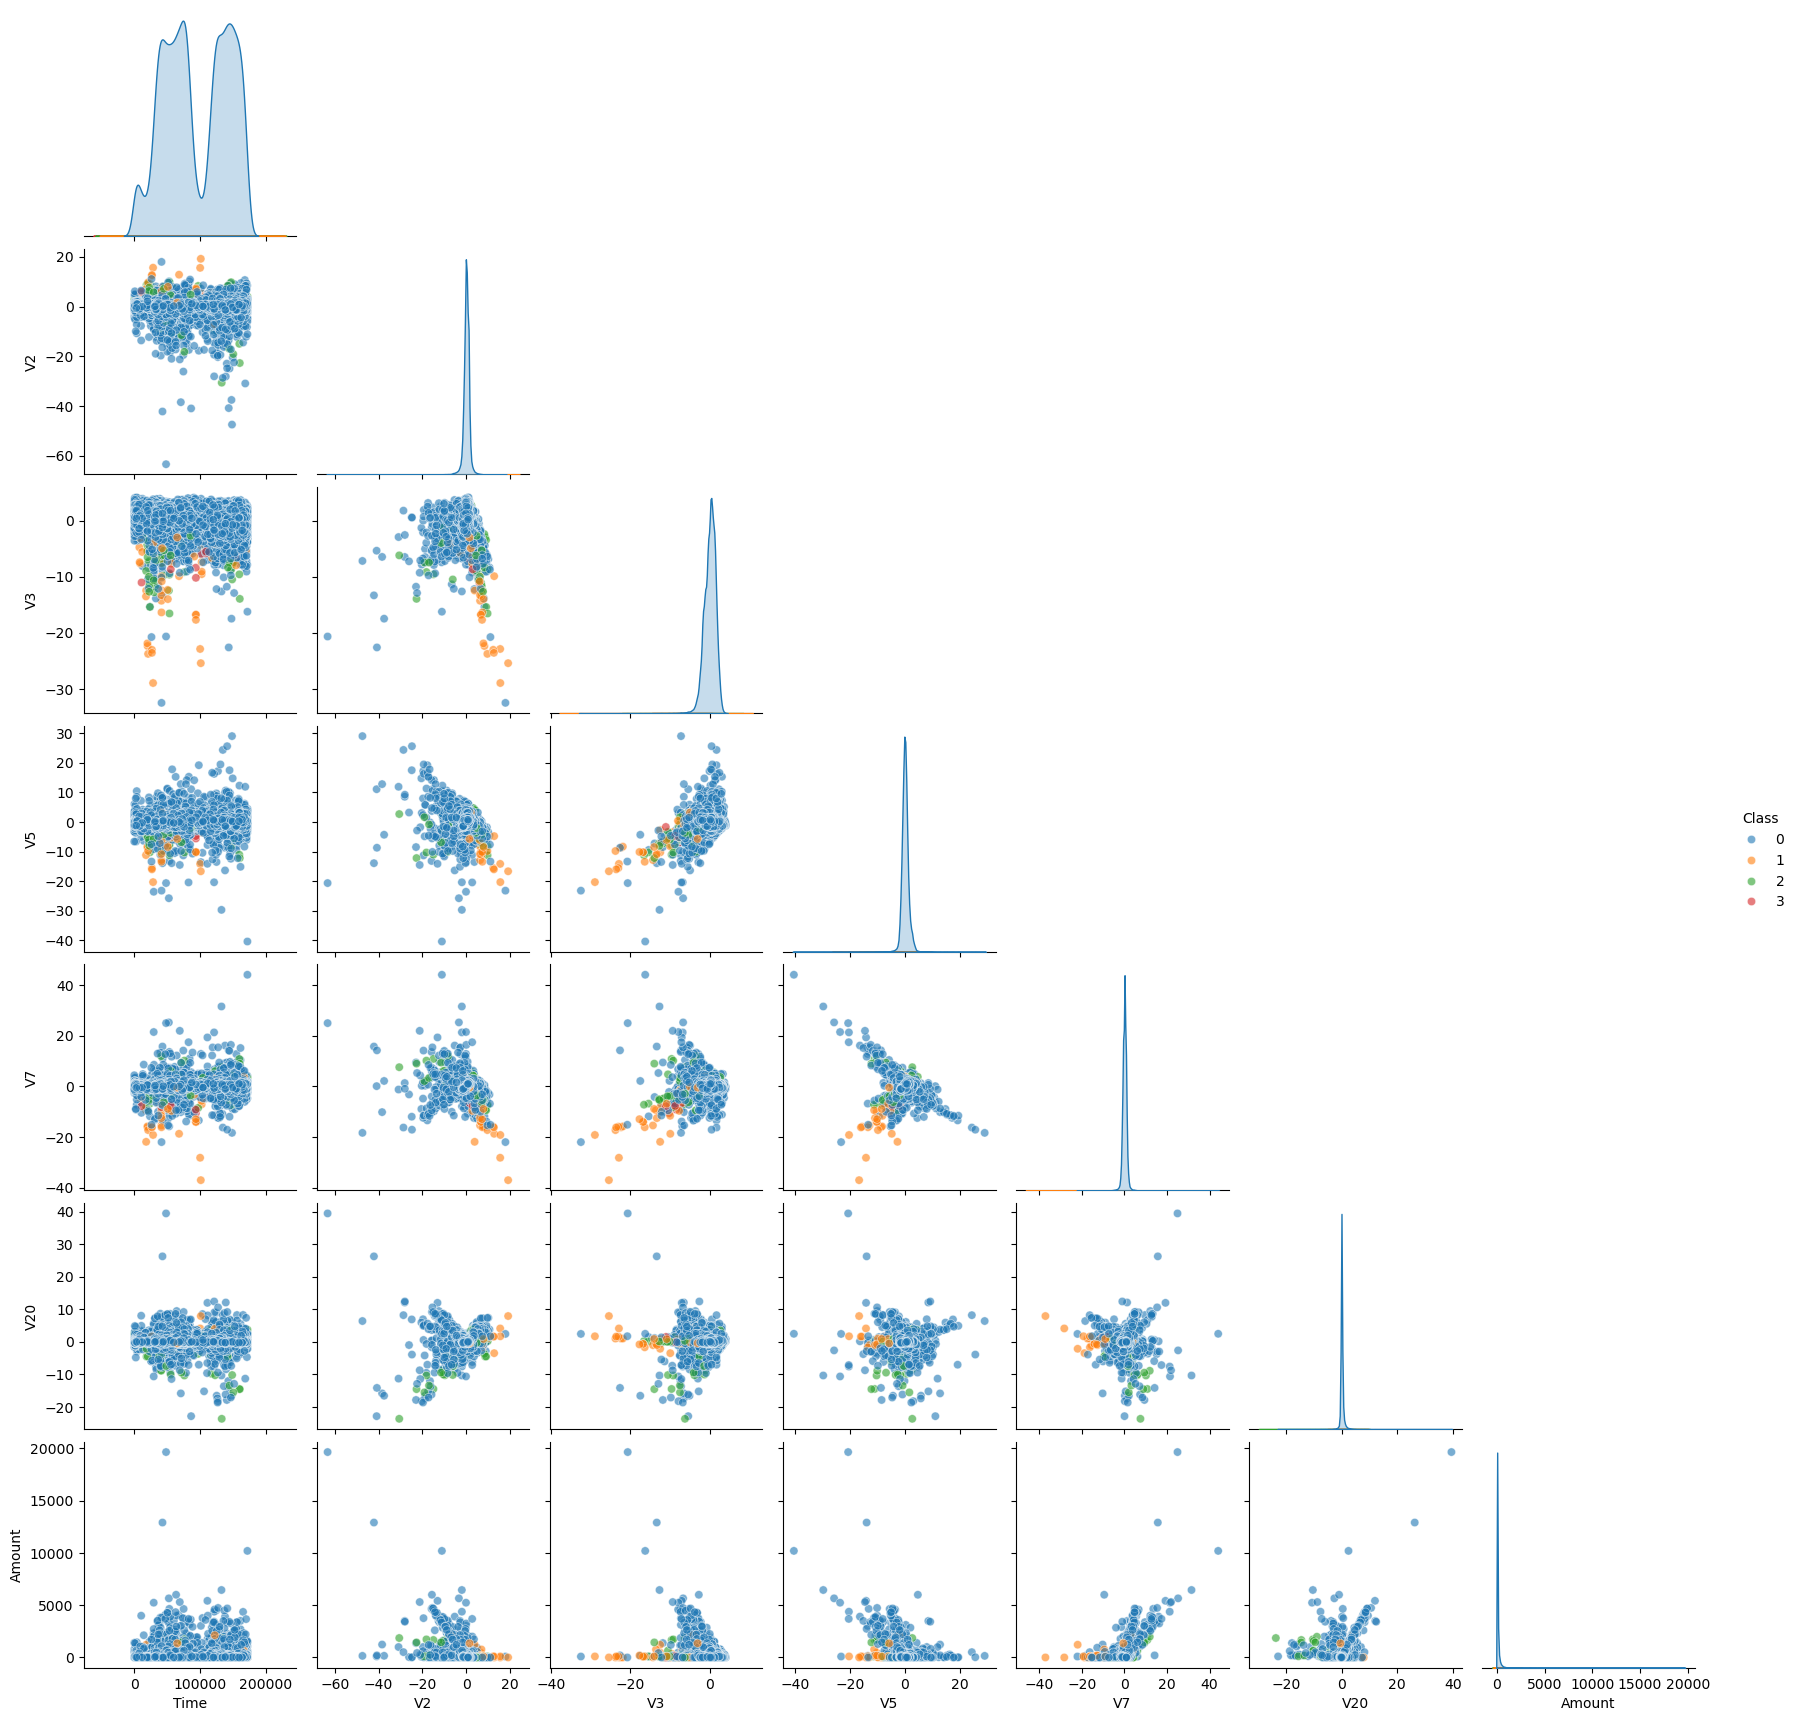

In [ ]:
# Нормализация признаков
ocsvm_scaler = RobustScaler()
ocsvm_scaler.fit(X_train)
X_train_ocsvm = pd.DataFrame(ocsvm_scaler.transform(X_train), index=X_train.index, columns=df.columns)
X_val_ocsvm = pd.DataFrame(ocsvm_scaler.transform(X_val), index=X_val.index, columns=df.columns)

# Работа с моделью
param_grid = {'nu': np.arange(0.0017, 0.0020, 0.0001), 'kernel': ['rbf',  'sigmoid']}
ocsvm_anomalies = cv_processing(OCSVMOutliers(), param_grid, X_train=X_train_ocsvm, y_train=y_train, X_test=X_val_ocsvm)

print_all(SET_VAL, 'One-class SVM', X_val, y_val, ocsvm_anomalies, anomalies_only=True)

**Выводы по методу One-class SVM**:
1. В наилучем случае удалось определить 15 аномалий из исходных 99 (15%) при ню 0.19%, целевая метрика f1 для класса аномалий 0.14.
2. Данный метод показал наименьшую скорость выполнения, особенно для ядра 'liner'.

#### Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

class IsolationForestOutliers(BaseOutliersEstimator):
    """
    -----------
    Parameters:

    - contamination: float
        искомый процент аномалий
    - n_estimators
        количество деревьев 
    """
    def __init__(self, contamination=0.05, n_estimators=100):
        self.contamination = contamination
        self.n_estimators = n_estimators

    def fit(self, X, y=None):
        self.model = IsolationForest(n_estimators=self.n_estimators, 
                                     contamination=self.contamination, 
                                     random_state=10,
                                     bootstrap=True)
        self.model.fit(X)

    def predict(self, X):
        isolation_outliers = self.model.predict(X)
        return np.array([1 if label == -1 else 0 for label in isolation_outliers])

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры CV: {'contamination': np.float64(0.0019), 'n_estimators': 250}
Лучшая метрика обучения CV: 0.27055377315057866
Метрики классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.28      0.30      0.29        99

    accuracy                           1.00     56962
   macro avg       0.64      0.65      0.64     56962
weighted avg       1.00      1.00      1.00     56962


    Истинные аномалии: 
        Количество: 99
        Процент:   0.17%
    Предсказанные аномалии:
        Количество: 109
        Процент:   0.19%


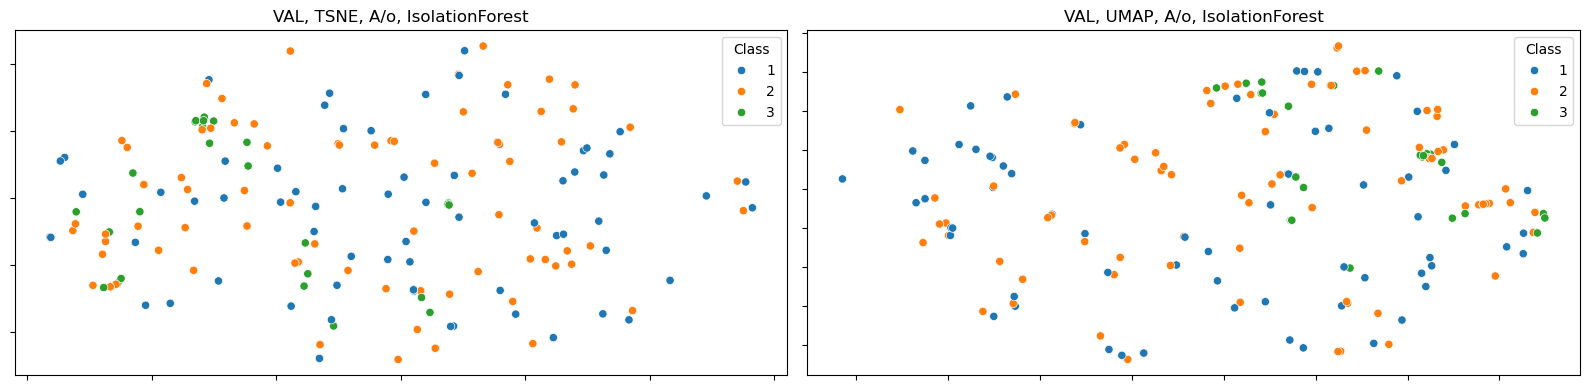

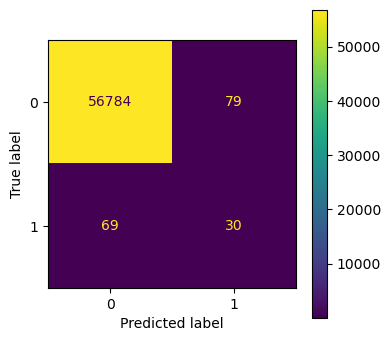

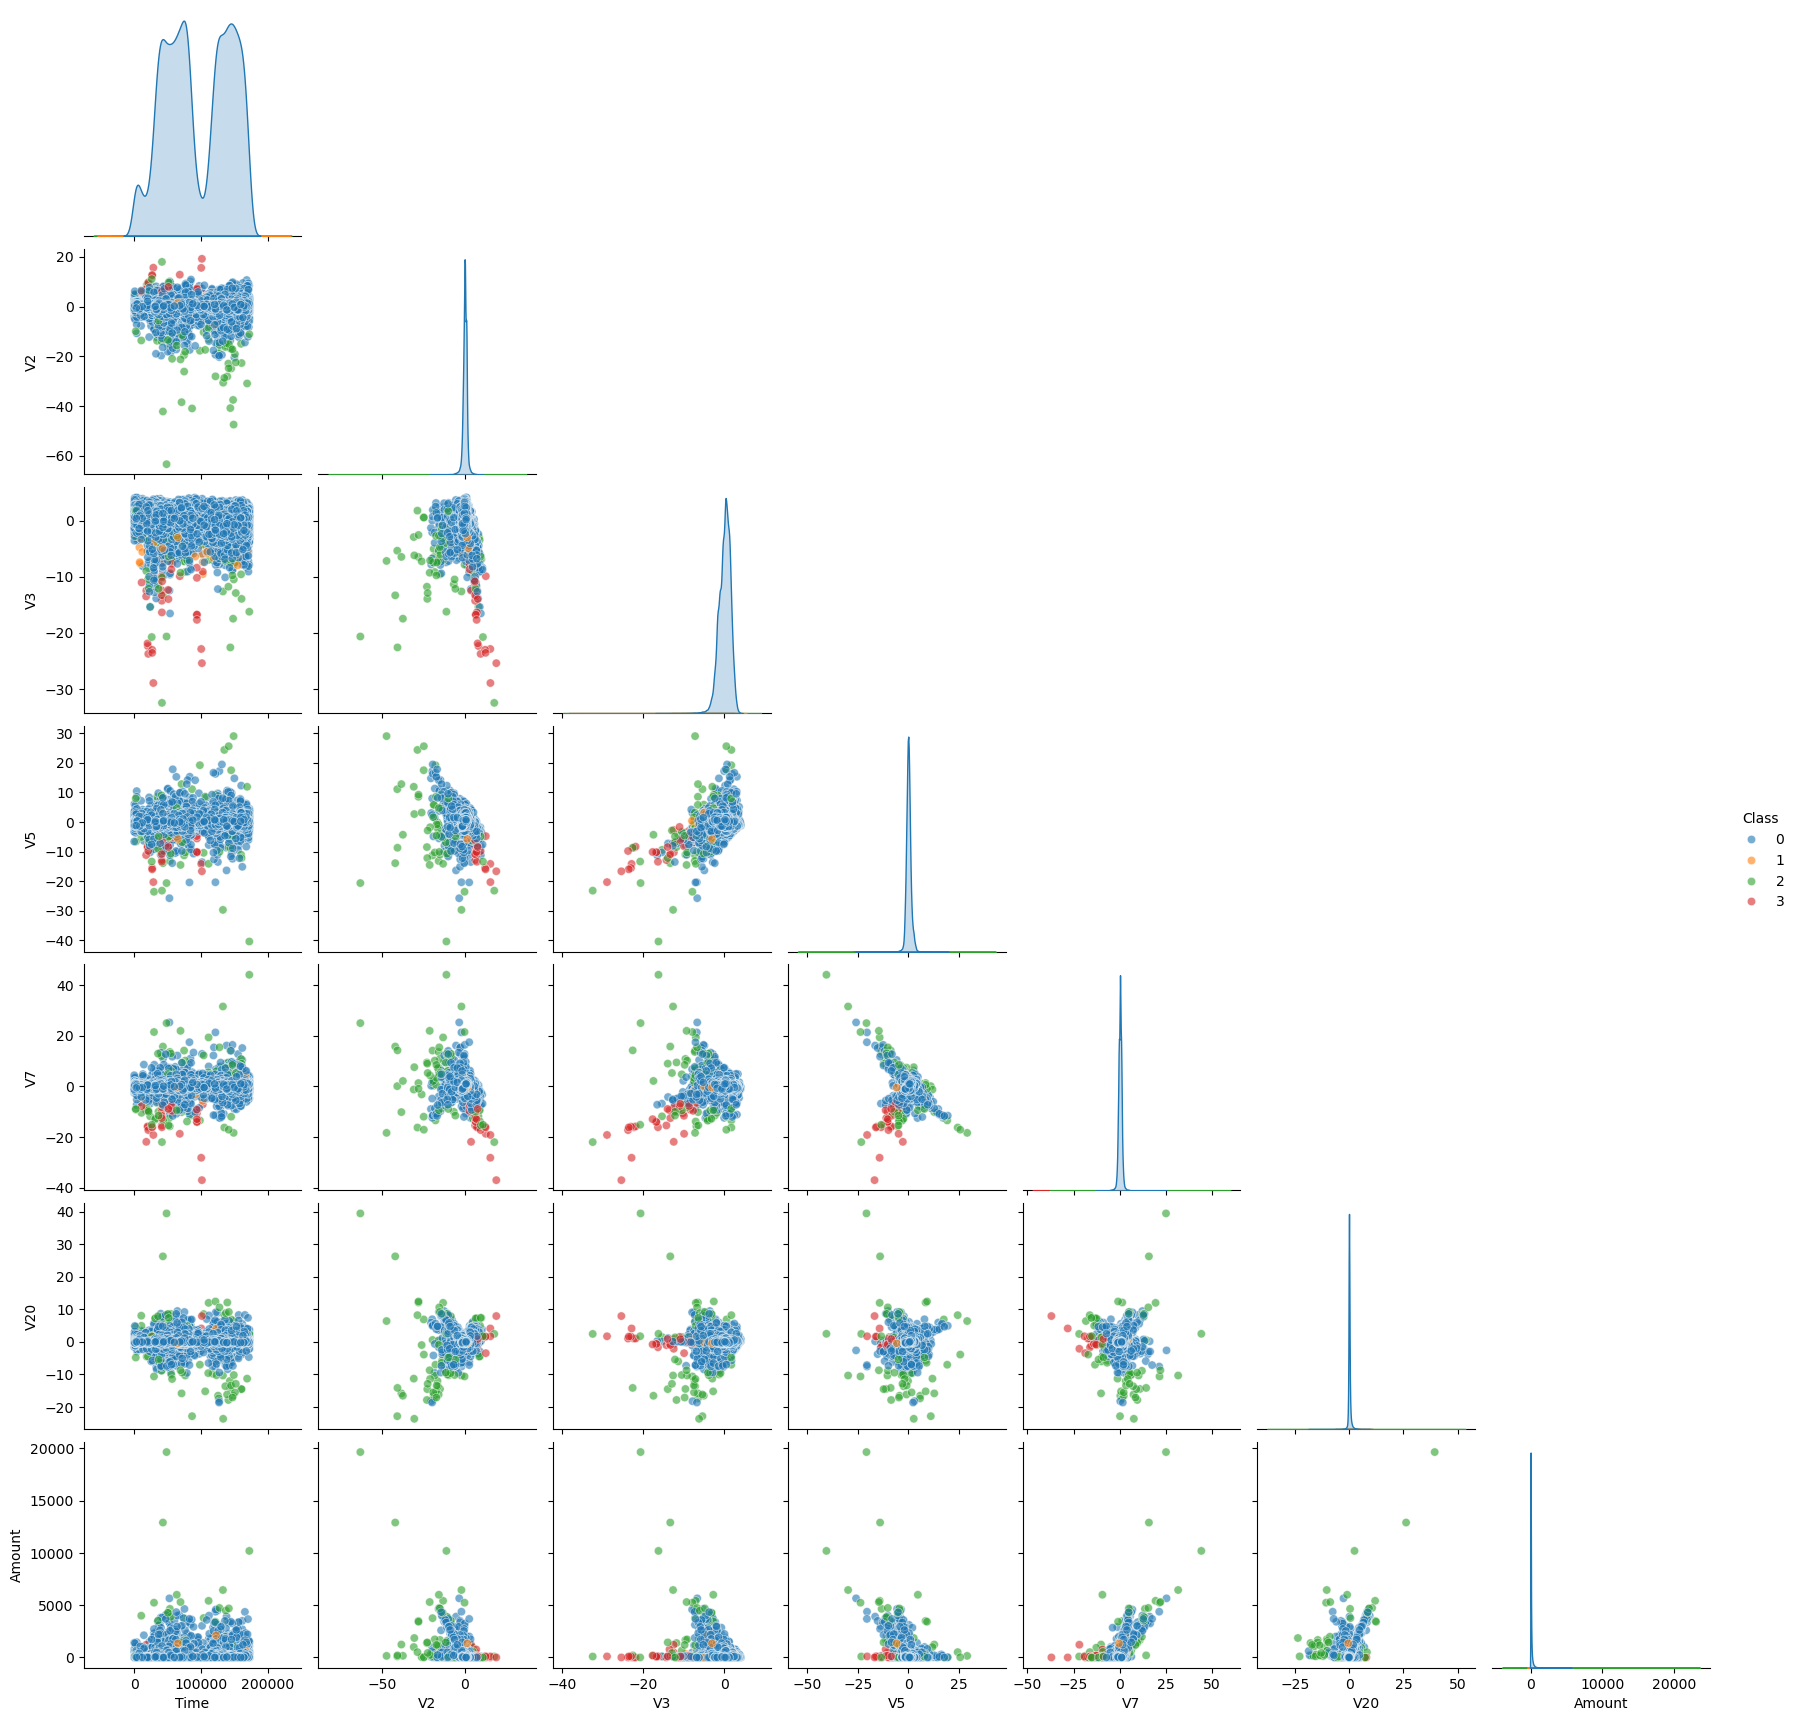

In [ ]:
X_train_iso= X_train
X_val_iso = X_val

# Работа с моделью
param_grid = {'contamination': np.arange(0.0017, 0.0020, 0.0001), 'n_estimators': range(100, 350, 50)}
iso_anomalies = cv_processing(IsolationForestOutliers(), param_grid, X_train=X_train_iso, y_train=y_train, X_test=X_val_iso)

print_all(SET_VAL, 'IsolationForest', X_val, y_val, iso_anomalies, anomalies_only=True)

**Выводы по методу IsolationForest**:
1. В наилучем случае удалось определить 30 аномалий из исходных 99 (30%) при заданном проценте аномалий 0.19% и 250 деревьях, целевая метрика f1 для класса аномалий 0.29.
2. Лучший результат по целевой метрике.

### Итоговый вывод

|Алгоритм|Совпавшее предсказание, %|f1|Комментарий|
|-|-|-|-|
|3-sigma|36|0.24|Результат оказался чувствительным к случайности при трансформации признаков к нормальному распределению|
|Box-plot|18|0.05|Худший результат|
|Distance-based|38|0.22|Стабильный и быстрый результат|
|DBSCAN|38|0.16|Базовый алгоритм не смог справиться с большим объемеом данных|
|One-class SVM|15|0.14|Медленный и неточный|
|IsolationForest|30|0.29|Лучший результат, хорошая скорость вычисления|


Проверяю итоговые метрики на тестовом наборе для лучшего алгоритма IsolationForest

Метрики классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.27      0.29      0.28        98

    accuracy                           1.00     56962
   macro avg       0.64      0.64      0.64     56962
weighted avg       1.00      1.00      1.00     56962


    Истинные аномалии: 
        Количество: 98
        Процент:   0.17%
    Предсказанные аномалии:
        Количество: 102
        Процент:   0.18%


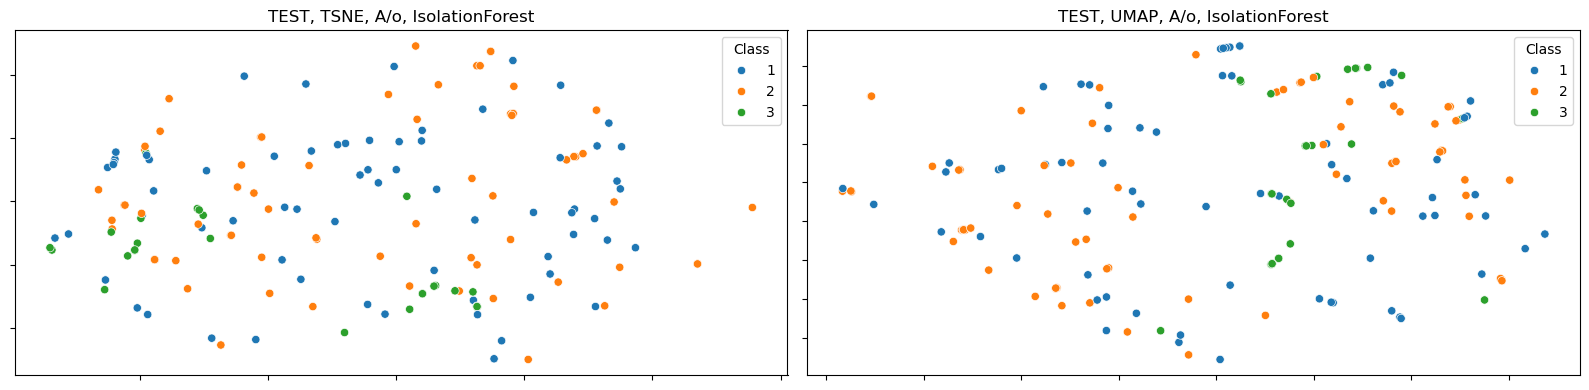

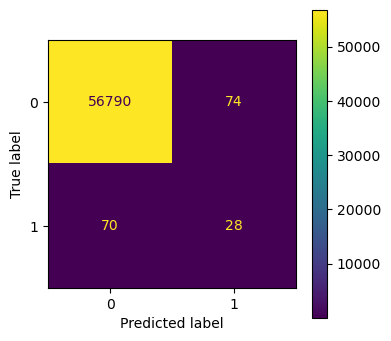

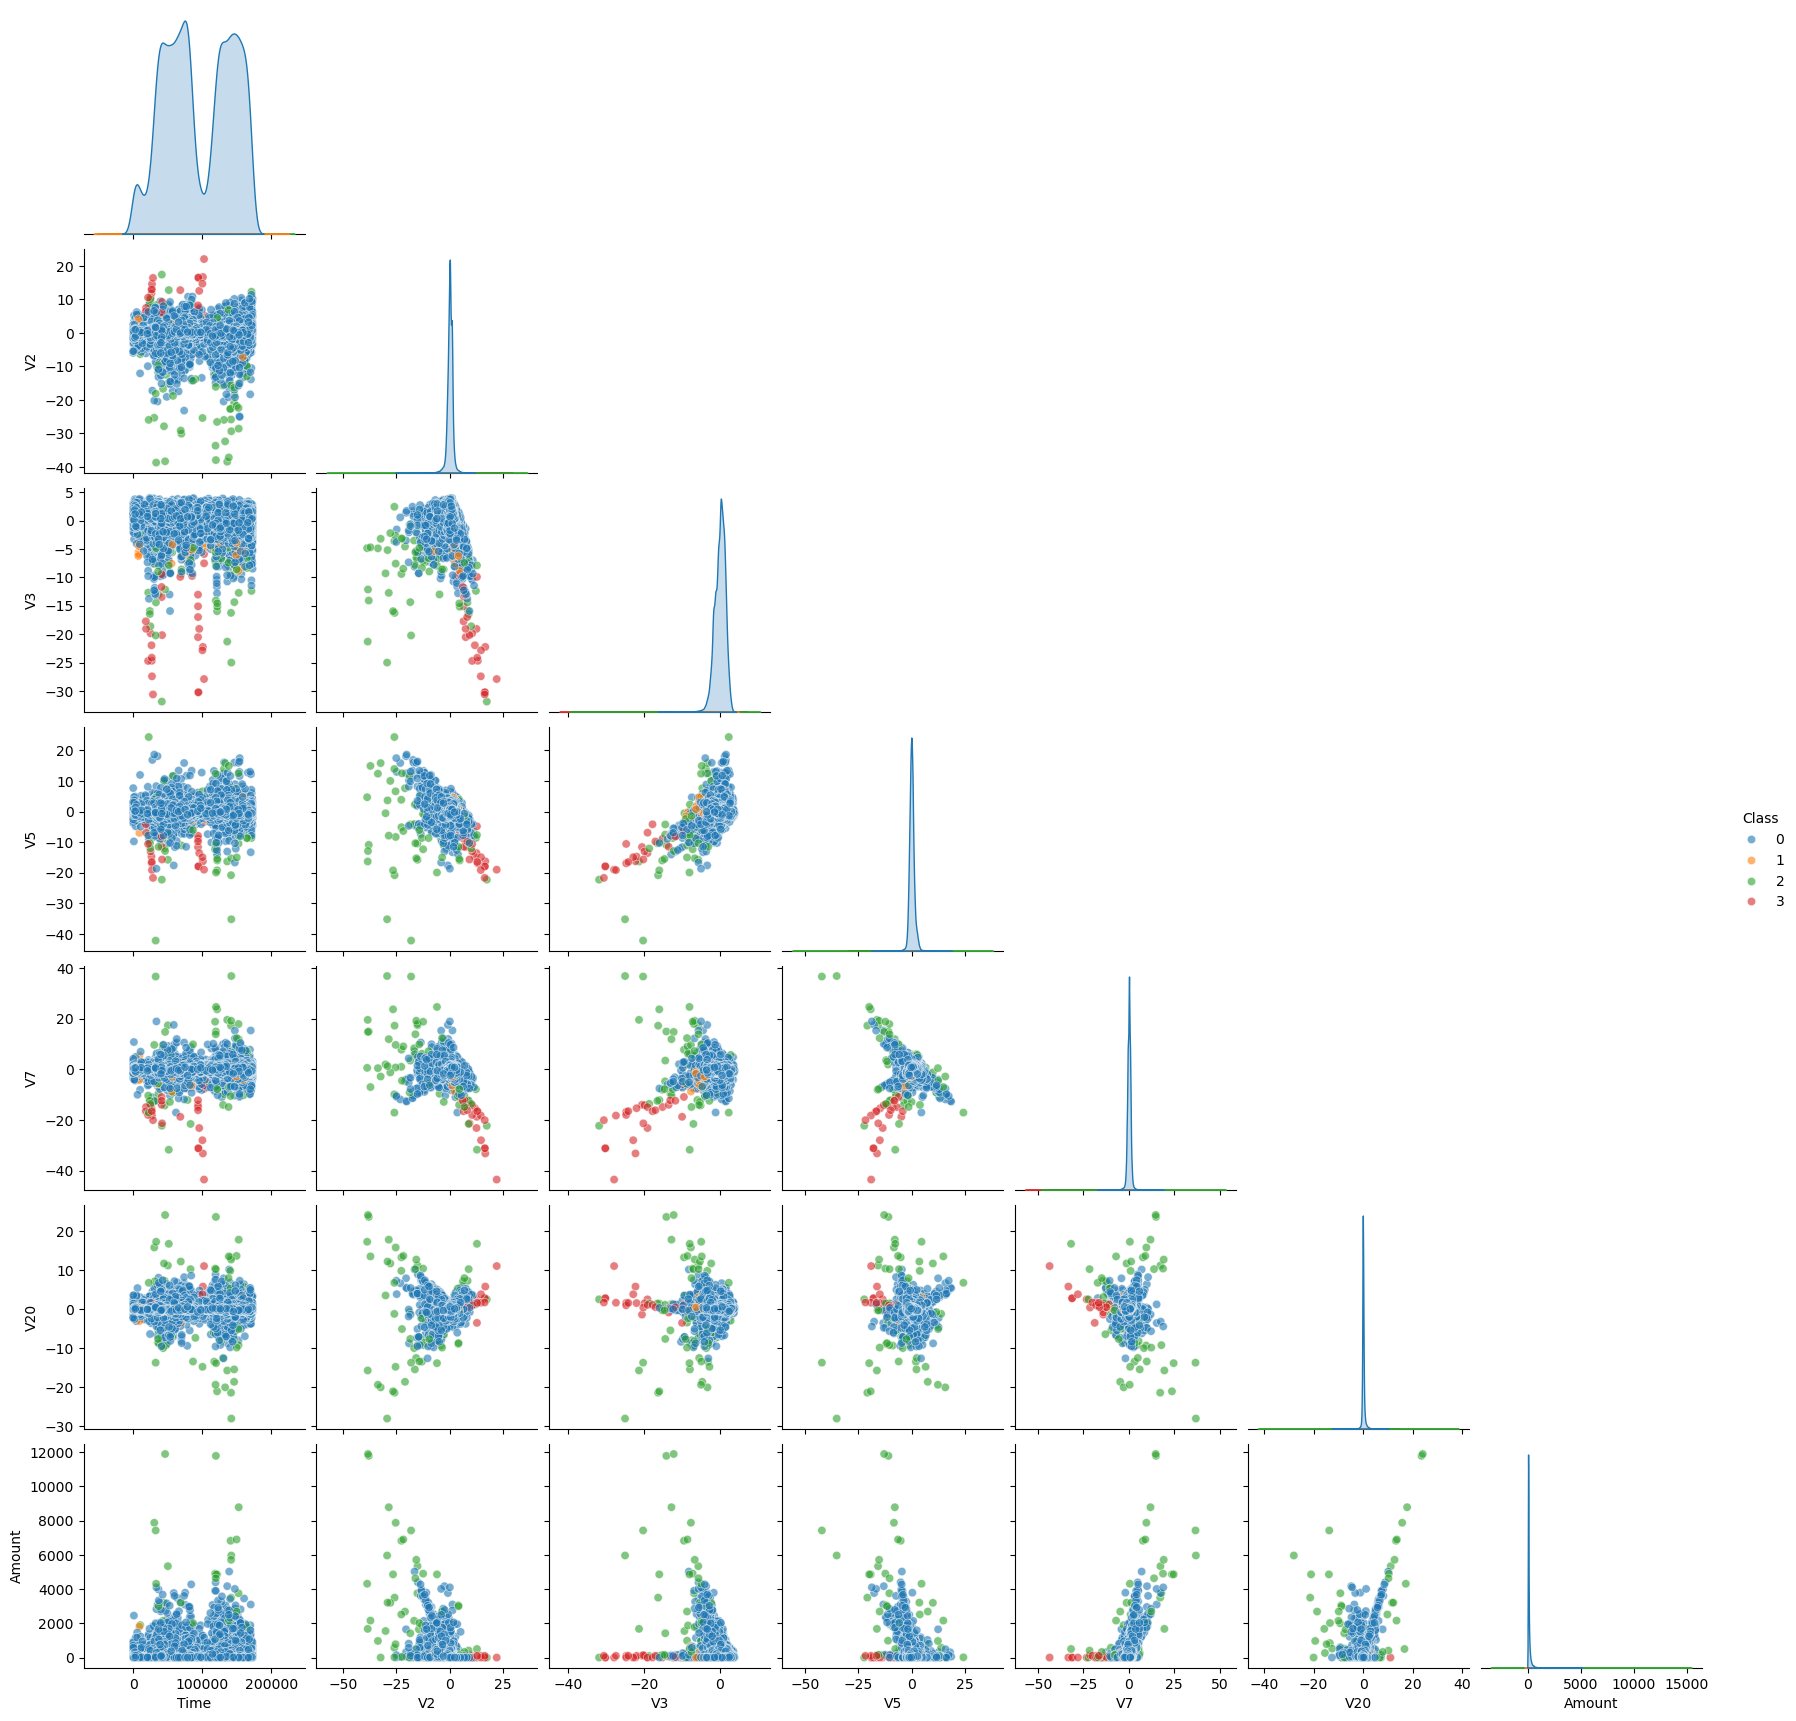

In [36]:
model = IsolationForestOutliers(contamination=0.0019, n_estimators=250)
model.fit(X_train)
result_anomalies = model.predict(X_test)

print_all(SET_TEST, 'IsolationForest', X_test, y_test, result_anomalies, anomalies_only=True)

**Вывод по итоговой модели**:\
Полученное на валидационном наблоре качество подтверждается - совпало 28 аномалий из 99 при метрике f1 для класса аномалий 0.28